# Ichimoku Nifty 200 - Execution-Price Audit Run
Strategy `('price_kijun','strong')` | trail `{'kind':'pct','value':30,'be':True}` | Rs 5,00,000 | 10 positions | 10% compounding allocation | SL 12% | target 24% (book 50%) | entry at close | ROC ranking | **slippage = 0**.

**What changed vs the previous notebook: recording only.** Signals, exits, trail, breakeven, ranking, sizing and portfolio logic are untouched.
- The simulator now captures the raw execution price (`price_row[s]`, or the fill computed in the loop) **at the moment the order executes**, together with the OHLC bar it came from, and stores it in the trade record and in an execution ledger.
- Nothing is derived afterwards from `invested/qty`, P&L or returns.
- Section 6 re-checks every trade against the same OHLC arrays and against the source DataFrames.

In [1]:
# !pip install yfinance pandas numpy matplotlib requests
import io, os, math, warnings
import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
pd.set_option("display.width", 220); pd.set_option("display.max_columns", 60)

## 1. Configuration

In [2]:
CFG = dict(
    tenkan=9, kijun=26, senkou_b=52, displacement=26,
    capital=500_000, max_positions=10, alloc_pct=10,           # alloc_pct of CURRENT equity -> compounding
    sl_pct=12, tp_pct=24, book_fraction=0.5,
    commission_pct=0.10, slippage_ticks=0, tick_size=0.05,     # ZERO slippage for this run
)
STRATEGY = ("price_kijun", "strong")
TRAIL    = dict(kind="pct", value=30, be=True)
ENTRY_AT = "close"          # "close" or "next_open"
RANK_BY  = "roc"
DATA_START, TRADE_START, END = "2014-01-01", "2015-01-01", None

# Price basis used for BOTH signals and execution.
#   "raw"      -> yfinance auto_adjust=False : Open/High/Low/Close as quoted (split-adjusted by Yahoo, NOT dividend-adjusted)
#   "adjusted" -> yfinance auto_adjust=True  : dividend+split adjusted (prices will NOT match the exchange's quoted prices)
PRICE_MODE = "raw"

DATA_SOURCE, CSV_FOLDER, SYMBOL_LIMIT = "yfinance", "data", None    # csv_folder: data/SYMBOL.csv with Date,Open,High,Low,Close
CACHE_FILE = f"nifty200_prices_{PRICE_MODE}_2014.pkl"

PRINT_ALL_TRADES = True     # print the diagnostic block for every trade (also always written to trade_validation_log.txt)

## 2. Data

In [3]:
def load_nifty200_symbols():
    url = "https://archives.nseindia.com/content/indices/ind_nifty200list.csv"
    try:
        r = requests.get(url, headers={"User-Agent": "Mozilla/5.0"}, timeout=20); r.raise_for_status()
        return pd.read_csv(io.StringIO(r.text))["Symbol"].str.strip().tolist()
    except Exception as e:
        print("NSE download failed:", e)
    if os.path.exists("ind_nifty200list.csv"):
        return pd.read_csv("ind_nifty200list.csv")["Symbol"].str.strip().tolist()
    if os.path.exists("nifty200.txt"):
        return [s.strip() for s in open("nifty200.txt") if s.strip()]
    raise RuntimeError("Put ind_nifty200list.csv or nifty200.txt (one symbol per line) next to the notebook.")

def _clean(df):
    df = df.rename(columns=str.title)[["Open", "High", "Low", "Close"]].dropna()
    df.index = pd.to_datetime(df.index).tz_localize(None)
    return df.sort_index()

# ------------------------------------------------------------------
# FIX: the old load_data() called yf.download() on a 40-ticker batch
# with threads=True. When Yahoo rate-limits / hiccups, that batch call
# can come back with EVERY ticker in it reporting
# "possibly delisted; no price data found" (they aren't actually
# delisted - the batch/threaded request just failed), and it can also
# hang indefinitely in yfinance's internal polling loop, forcing a
# manual KeyboardInterrupt - which throws away every symbol downloaded
# so far because nothing was saved incrementally.
#
# Fix: download one symbol at a time (far more reliable against
# Yahoo's rate limits than the multi-ticker/threaded path), retry each
# symbol a few times with backoff, save progress to disk every 20
# symbols (and immediately on Ctrl-C) so an interrupt or crash never
# loses work, and resume automatically from that partial cache next run.
# ------------------------------------------------------------------
def load_data(symbols):
    data = {}
    if DATA_SOURCE == "csv_folder":
        for s in symbols:
            p = os.path.join(CSV_FOLDER, f"{s}.csv")
            if os.path.exists(p):
                data[s] = _clean(pd.read_csv(p, parse_dates=[0], index_col=0)).loc[DATA_START:END]
        return data

    import yfinance as yf
    import time as _time

    if os.path.exists(CACHE_FILE):
        print("Loading cached prices:", CACHE_FILE); return pd.read_pickle(CACHE_FILE)

    partial_file = CACHE_FILE + ".partial"
    if os.path.exists(partial_file):
        data = pd.read_pickle(partial_file)
        print(f"Resuming from partial cache: {len(data)} symbol(s) already downloaded -> {partial_file}")

    MAX_RETRIES        = 3
    RETRY_SLEEP_SEC    = 2.0     # doubled on each retry
    INTER_SYMBOL_SLEEP = 0.15    # small pause between symbols to avoid rate-limiting
    SAVE_EVERY         = 20

    remaining = [s for s in symbols if s not in data]
    failed = []
    print(f"Downloading {len(remaining)} symbol(s) individually (per-ticker, with retries)...")

    try:
        for n, s in enumerate(remaining, 1):
            ticker = f"{s}.NS"
            d, last_err = None, None
            for attempt in range(1, MAX_RETRIES + 1):
                try:
                    raw = yf.Ticker(ticker).history(
                        start=DATA_START, end=END, interval="1d",
                        auto_adjust=(PRICE_MODE == "adjusted"), actions=False, timeout=20,
                    )
                    if raw is not None and len(raw):
                        cand = _clean(raw)
                        if len(cand):
                            d = cand
                            break
                    last_err = "empty result"
                except Exception as e:
                    last_err = str(e)
                if attempt < MAX_RETRIES:
                    _time.sleep(RETRY_SLEEP_SEC * attempt)

            if d is not None:
                data[s] = d
            else:
                failed.append((s, last_err))

            if n % SAVE_EVERY == 0 or n == len(remaining):
                pd.to_pickle(data, partial_file)
                print(f"  [{n}/{len(remaining)}] ok={len(data)} failed={len(failed)} "
                      f"(progress saved -> {partial_file})")

            _time.sleep(INTER_SYMBOL_SLEEP)

    except KeyboardInterrupt:
        pd.to_pickle(data, partial_file)
        print(f"\n⏸ Interrupted - progress saved ({len(data)} symbol(s)) to {partial_file}. "
              f"Re-run this cell to resume from where it stopped.")
        raise

    if failed:
        print(f"\n{len(failed)} symbol(s) had no data after {MAX_RETRIES} attempt(s) each:")
        for s, err in failed[:20]:
            print(f"   {s}: {err}")
        if len(failed) > 20:
            print(f"   ... and {len(failed) - 20} more")

    pd.to_pickle(data, CACHE_FILE)
    if os.path.exists(partial_file):
        os.remove(partial_file)
    print(f"\nDone: {len(data)}/{len(symbols)} symbol(s) loaded -> cached to {CACHE_FILE}")
    return data


In [4]:
# LOAD
symbols = load_nifty200_symbols()
if SYMBOL_LIMIT: symbols = symbols[:SYMBOL_LIMIT]
data = load_data(symbols)
print(f"{len(data)} symbols loaded out of {len(symbols)} | PRICE_MODE = {PRICE_MODE}")

  [20/200] ok=20 failed=0 (progress saved -> nifty200_prices_raw_2014.pkl.partial)
  [40/200] ok=40 failed=0 (progress saved -> nifty200_prices_raw_2014.pkl.partial)
  [60/200] ok=60 failed=0 (progress saved -> nifty200_prices_raw_2014.pkl.partial)
  [80/200] ok=80 failed=0 (progress saved -> nifty200_prices_raw_2014.pkl.partial)
  [100/200] ok=100 failed=0 (progress saved -> nifty200_prices_raw_2014.pkl.partial)
  [120/200] ok=120 failed=0 (progress saved -> nifty200_prices_raw_2014.pkl.partial)
  [140/200] ok=140 failed=0 (progress saved -> nifty200_prices_raw_2014.pkl.partial)
  [160/200] ok=160 failed=0 (progress saved -> nifty200_prices_raw_2014.pkl.partial)
  [180/200] ok=180 failed=0 (progress saved -> nifty200_prices_raw_2014.pkl.partial)
  [200/200] ok=200 failed=0 (progress saved -> nifty200_prices_raw_2014.pkl.partial)

Done: 200/200 symbol(s) loaded -> cached to nifty200_prices_raw_2014.pkl
200 symbols loaded out of 200 | PRICE_MODE = raw


## 3. Indicators, signals and price panel (unchanged logic)

In [5]:
xover = lambda a, b: (a > b) & (a.shift(1) <= b.shift(1))

def add_indicators(df, c):
    hi, lo, cl = df["High"], df["Low"], df["Close"]
    donch = lambda n: (lo.rolling(n).min() + hi.rolling(n).max()) / 2
    df = df.copy()
    df["tenkan"], df["kijun"] = donch(c["tenkan"]), donch(c["kijun"])
    df["span_a"] = (df["tenkan"] + df["kijun"]) / 2
    df["span_b"] = donch(c["senkou_b"])
    sh = c["displacement"] - 1
    df["adj_a"], df["adj_b"] = df["span_a"].shift(sh), df["span_b"].shift(sh)
    tr = pd.concat([hi - lo, (hi - cl.shift()).abs(), (lo - cl.shift()).abs()], axis=1).max(axis=1)
    df["atr"] = tr.rolling(14).mean()
    df["roc"] = cl.pct_change(26)
    return df

def entry_signal(df, strategy, variant):
    c = df["Close"]
    over, under = c > df["adj_a"], c < df["adj_b"]
    inside = (c > df["adj_a"]) & (c < df["adj_b"])
    zone = {"strong": over, "neutro": inside, "weak": under}
    if strategy == "tenkan_kijun":    s = xover(df["tenkan"], df["kijun"]) & zone[variant]
    elif strategy == "price_kijun":   s = xover(c, df["kijun"]) & zone[variant]
    elif strategy == "kumo_breakout": s = xover(c, df["adj_a"]) & (c > df["adj_a"]) & (c > df["adj_b"])
    elif strategy == "kumo_twist":    s = xover(df["adj_a"], df["adj_b"]) & zone[variant]
    return s.fillna(False)

def build_panel(data, cfg, strategy):
    dates = pd.DatetimeIndex(sorted(set().union(*[d.index for d in data.values()])))
    fields = {k: {} for k in ["Open", "High", "Low", "Close", "kijun", "atr", "roc"]}
    sig = {}
    for sym, df in data.items():
        if len(df) < cfg["senkou_b"] + cfg["displacement"] + 5: continue
        d = add_indicators(df, cfg)
        for k in fields: fields[k][sym] = d[k]
        sig[sym] = entry_signal(d, *strategy)
    syms = list(fields["Close"].keys())
    arr = lambda dct: pd.DataFrame(dct).reindex(index=dates, columns=syms).values.astype(float)
    P = {k: arr(v) for k, v in fields.items()}
    P["Cff"] = pd.DataFrame(P["Close"]).ffill().values
    P["dates"], P["syms"] = dates, syms
    P["sig"] = pd.DataFrame(sig).reindex(index=dates, columns=syms).fillna(False).values.astype(bool)
    return P

P = build_panel(data, CFG, STRATEGY)
print("Panel:", P["Close"].shape, "| dates", P["dates"][0].date(), "->", P["dates"][-1].date())

Panel: (3146, 200) | dates 2014-01-01 -> 2026-09-25


## 4. Simulator (same logic; execution prices captured at execution time)
Where the recording now happens:
- **Entry:** `try_enter` reads `raw = price_row[s]`, asserts it is finite, and uses `px = raw` when slippage is 0. `raw`, `px` and the entry bar's O/H/L/C are stored on the position immediately.
- **Exit:** every `sell(...)` call receives the fill computed in the main loop (`min(o, sl_px)`, `max(o, tp_px)`, `min(o, lvl)`, or `c`). `sell` stores the raw fill, the post-slippage fill, the exit bar's O/H/L/C, the trigger level and the rule used.
- **Trade record:** built inside `sell` when the last share is sold, with fields copied from what was captured, never recomputed. T1 leg and every execution are also appended to `ledger`.

In [6]:
def simulate(P, cfg, trail, entry_at=ENTRY_AT, rank_by=RANK_BY):
    sig = P["sig"]
    O, H, L, C, Cff, KJ, ATR, ROC = (P[k] for k in ["Open", "High", "Low", "Close", "Cff", "kijun", "atr", "roc"])
    dates, syms = P["dates"], P["syms"]
    T, N = C.shape
    slip = cfg["slippage_ticks"] * cfg["tick_size"]; comm = cfg["commission_pct"] / 100
    sl_f, tp_f = 1 - cfg["sl_pct"] / 100, 1 + cfg["tp_pct"] / 100
    start_i = int(np.searchsorted(dates.values, np.datetime64(TRADE_START)))
    cash = float(cfg["capital"]); pos = {}; trades = []; ledger = []
    equity = np.full(T, float(cfg["capital"])); npos = np.zeros(T, int)

    def mark(i): return cash + sum(p["qty"] * Cff[i, s] for s, p in pos.items())
    def bar(i, s): return dict(open=O[i, s], high=H[i, s], low=L[i, s], close=C[i, s])

    def sell(p, qty, raw_fill, i, reason, rule, level=np.nan):
        nonlocal cash
        assert np.isfinite(raw_fill), f"non-finite exit fill {syms[p['s']]} {dates[i]}"
        px = raw_fill if slip == 0 else raw_fill - slip          # slip == 0 -> execution price is the untouched fill
        cash += qty * px * (1 - comm); p["proceeds"] += qty * px * (1 - comm); p["qty"] -= qty
        b = bar(i, p["s"])
        ledger.append(dict(symbol=syms[p["s"]], date=dates[i], action="EXIT_" + reason, qty=qty, raw_px=raw_fill, fill_px=px,
                           open=b["open"], high=b["high"], low=b["low"], close=b["close"], rule=rule, level=level))
        if reason in ("T1",):
            p.update(t1_date=dates[i], t1_raw_px=raw_fill, t1_px=px, t1_qty=qty, t1_level=level)
        if p["qty"] == 0:
            pnl = p["proceeds"] - p["cost"]
            trades.append(dict(symbol=syms[p["s"]], entry_date=dates[p["entry_i"]], exit_date=dates[i],
                               entry_px=p["entry_px"], exit_px=px, entry_raw_px=p["entry_raw_px"], exit_raw_px=raw_fill,
                               qty=p["qty0"], invested=p["cost"], pnl=pnl, ret_pct=pnl / p["cost"] * 100,
                               hit_target=p["t1"], reason=reason, peak_gain_pct=(p["peak"] / p["entry_px"] - 1) * 100, days=i - p["entry_i"],
                               entry_open=p["eb"]["open"], entry_high=p["eb"]["high"], entry_low=p["eb"]["low"], entry_close=p["eb"]["close"],
                               exit_open=b["open"], exit_high=b["high"], exit_low=b["low"], exit_close=b["close"],
                               fill_rule=rule, exit_level=level, sl_px=p["sl_px"], tp_px=p["tp_px"],
                               t1_date=p.get("t1_date", pd.NaT), t1_raw_px=p.get("t1_raw_px", np.nan), t1_px=p.get("t1_px", np.nan),
                               t1_qty=p.get("t1_qty", 0)))
            del pos[p["s"]]

    def try_enter(row, price_row, eq, i):
        nonlocal cash
        free = cfg["max_positions"] - len(pos)
        if free <= 0: return
        cand = [s for s in np.flatnonzero(sig[row] & ~np.isnan(price_row)) if s not in pos]
        if not cand: return
        if rank_by == "roc":
            cand.sort(key=lambda s: -(ROC[row, s] if not np.isnan(ROC[row, s]) else -9))
        for s in cand[:free]:
            raw = price_row[s]                                    # exact execution price from the simulator's own OHLC array
            assert np.isfinite(raw), f"non-finite entry price {syms[s]} {dates[i]}"
            px = raw if slip == 0 else raw + slip                 # slip == 0 -> px IS raw
            q = min(math.floor(cfg["alloc_pct"] / 100 * eq / (px * (1 + comm))), math.floor(cash / (px * (1 + comm))))
            if q < 1: continue
            cost = q * px * (1 + comm); cash -= cost
            b = bar(i, s)
            pos[s] = dict(s=s, entry_i=i, entry_px=px, entry_raw_px=raw, eb=b, qty0=q, qty=q, cost=cost, proceeds=0.0, t1=False,
                          peak=px, sl_px=px * sl_f, tp_px=px * tp_f)
            ledger.append(dict(symbol=syms[s], date=dates[i], action="ENTRY", qty=q, raw_px=raw, fill_px=px,
                               open=b["open"], high=b["high"], low=b["low"], close=b["close"],
                               rule="close" if entry_at == "close" else "open", level=np.nan))

    for i in range(start_i, T):
        if entry_at == "next_open" and i > start_i:
            try_enter(i - 1, O[i], equity[i - 1], i)
        for s in list(pos):
            p = pos[s]; o, h, l, c = O[i, s], H[i, s], L[i, s], C[i, s]
            if np.isnan(h) or np.isnan(l) or np.isnan(o): continue
            if not p["t1"]:
                if l <= p["sl_px"]:
                    sell(p, p["qty"], min(o, p["sl_px"]), i, "SL", "min(open,sl_px)", p["sl_px"])
                elif h >= p["tp_px"]:
                    fill = max(o, p["tp_px"])
                    half = int(round(p["qty0"] * cfg["book_fraction"]))
                    if p["qty0"] < 2: sell(p, p["qty"], fill, i, "TARGET_FULL", "max(open,tp_px)", p["tp_px"]); continue
                    half = min(max(half, 1), p["qty0"] - 1)
                    sell(p, half, fill, i, "T1", "max(open,tp_px)", p["tp_px"]); p["t1"] = True; p["peak"] = max(p["peak"], h)
                else:
                    p["peak"] = max(p["peak"], h)
            else:
                lvl = -np.inf
                if trail["kind"] == "pct":
                    lvl = p["peak"] * (1 - trail["value"] / 100)
                elif trail["kind"] == "atr" and not np.isnan(ATR[i - 1, s]):
                    lvl = p["peak"] - trail["value"] * ATR[i - 1, s]
                lvl = max(lvl, p["sl_px"])
                if trail.get("be", False): lvl = max(lvl, p["entry_px"])
                if l <= lvl:
                    sell(p, p["qty"], min(o, lvl), i, "TRAIL", "min(open,trail_level)", lvl)
                elif trail["kind"] == "kijun" and not np.isnan(KJ[i, s]) and c < KJ[i, s]:
                    sell(p, p["qty"], c, i, "TRAIL", "close", KJ[i, s])
                else:
                    p["peak"] = max(p["peak"], h)
        if entry_at == "close":
            try_enter(i, C[i], mark(i), i)
        equity[i] = mark(i); npos[i] = len(pos)

    for s, p in list(pos.items()):      # still open at the end: mark-to-market at last close (equity already reflects it)
        last = Cff[T - 1, s]; val = p["qty"] * last * (1 - comm) + p["proceeds"]
        b = bar(T - 1, s)
        trades.append(dict(symbol=syms[s], entry_date=dates[p["entry_i"]], exit_date=dates[T - 1],
                           entry_px=p["entry_px"], exit_px=last, entry_raw_px=p["entry_raw_px"], exit_raw_px=last,
                           qty=p["qty0"], invested=p["cost"], pnl=val - p["cost"], ret_pct=(val - p["cost"]) / p["cost"] * 100,
                           hit_target=p["t1"], reason="OPEN", peak_gain_pct=(p["peak"] / p["entry_px"] - 1) * 100, days=T - 1 - p["entry_i"],
                           entry_open=p["eb"]["open"], entry_high=p["eb"]["high"], entry_low=p["eb"]["low"], entry_close=p["eb"]["close"],
                           exit_open=b["open"], exit_high=b["high"], exit_low=b["low"], exit_close=b["close"],
                           fill_rule="last_close(MTM)", exit_level=np.nan, sl_px=p["sl_px"], tp_px=p["tp_px"],
                           t1_date=p.get("t1_date", pd.NaT), t1_raw_px=p.get("t1_raw_px", np.nan), t1_px=p.get("t1_px", np.nan),
                           t1_qty=p.get("t1_qty", 0)))
    eq = pd.Series(equity[start_i:], index=dates[start_i:]); n_open = pd.Series(npos[start_i:], index=dates[start_i:])
    return pd.DataFrame(trades), eq, n_open, pd.DataFrame(ledger)


def metrics(eq, tr, n_open, cfg):
    yrs = (eq.index[-1] - eq.index[0]).days / 365.25
    cagr = ((eq.iloc[-1] / cfg["capital"]) ** (1 / yrs) - 1) * 100
    dd = (eq / eq.cummax() - 1).min() * 100
    r = eq.pct_change().dropna()
    out = dict(final_equity=round(eq.iloc[-1]), total_return_pct=round((eq.iloc[-1] / cfg["capital"] - 1) * 100, 1),
               CAGR_pct=round(cagr, 2), max_DD_pct=round(dd, 2), Calmar=round(cagr / abs(dd), 2) if dd < 0 else np.nan,
               Sharpe=round(r.mean() / r.std() * np.sqrt(252), 2) if r.std() > 0 else np.nan, trades=len(tr))
    if len(tr):
        w, l = tr[tr.pnl > 0], tr[tr.pnl <= 0]
        out.update(win_rate_pct=round(len(w) / len(tr) * 100, 1),
                   profit_factor=round(w.pnl.sum() / abs(l.pnl.sum()), 2) if len(l) and l.pnl.sum() else np.inf,
                   expectancy_pct=round(tr.ret_pct.mean(), 2), avg_days=round(tr.days.mean(), 1),
                   target_hit_pct=round(tr.hit_target.mean() * 100, 1), avg_slots_used=round(n_open.mean(), 2))
    return out

## 5. Run and export the actual stored execution prices

In [7]:
trades, eq, n_open, ledger = simulate(P, CFG, TRAIL)
print(f"{STRATEGY} | trail {TRAIL} | slippage_ticks={CFG['slippage_ticks']} | {eq.index[0].date()} -> {eq.index[-1].date()}")
display(pd.Series(metrics(eq, trades, n_open, CFG)).to_frame("value"))

cols = ["symbol", "entry_date", "entry_px", "entry_raw_px", "entry_open", "entry_high", "entry_low", "entry_close", "qty", "invested",
        "t1_date", "t1_px", "t1_raw_px", "t1_qty",
        "exit_date", "exit_px", "exit_raw_px", "exit_open", "exit_high", "exit_low", "exit_close", "exit_level", "fill_rule", "reason",
        "pnl", "ret_pct", "hit_target", "peak_gain_pct", "days", "sl_px", "tp_px"]
trades = trades[cols]
tag = f"{STRATEGY[0]}_{STRATEGY[1]}_{PRICE_MODE}"
trades.to_csv(f"trades_{tag}.csv", index=False)          # full float precision, no rounding
ledger.to_csv(f"executions_{tag}.csv", index=False)
eq.to_frame("equity").assign(open_positions=n_open).to_csv(f"equity_{tag}.csv")
print(f"Wrote trades_{tag}.csv ({len(trades)} trades), executions_{tag}.csv ({len(ledger)} executions), equity_{tag}.csv")
trades.head(10)

('price_kijun', 'strong') | trail {'kind': 'pct', 'value': 30, 'be': True} | slippage_ticks=0 | 2015-01-01 -> 2026-09-25


,value
final_equity,7668562.00
total_return_pct,1433.70
CAGR_pct,26.20
max_DD_pct,-28.26
Calmar,0.93
Sharpe,1.56
trades,132.00
win_rate_pct,52.30
profit_factor,5.25
expectancy_pct,43.74


Wrote trades_price_kijun_strong_raw.csv (132 trades), executions_price_kijun_strong_raw.csv (322 executions), equity_price_kijun_strong_raw.csv


,symbol,entry_date,entry_px,entry_raw_px,entry_open,entry_high,entry_low,entry_close,qty,invested,t1_date,t1_px,t1_raw_px,t1_qty,exit_date,exit_px,exit_raw_px,exit_open,exit_high,exit_low,exit_close,exit_level,fill_rule,reason,pnl,ret_pct,hit_target,peak_gain_pct,days,sl_px,tp_px
0,HINDALCO,2015-01-01,158.449997,158.449997,157.399994,159.000000,155.399994,158.449997,315,49961.660788,NaT,NaN,NaN,0,2015-01-15,139.435997,139.435997,143.550003,145.750000,138.350006,141.899994,139.435997,"min(open,sl_px)",SL,-6083.243973,-12.175824,False,2.208899,10,139.435997,196.477996
1,BANKINDIA,2015-01-15,300.850006,300.850006,303.350006,304.799988,298.049988,300.850006,168,50593.343826,NaT,NaN,NaN,0,2015-01-30,264.748005,264.748005,282.450012,285.299988,261.549988,266.250000,264.748005,"min(open,sl_px)",SL,-6160.156589,-12.175824,False,1.711814,10,264.748005,373.054008
2,GMRAIRPORT,2015-01-30,17.059155,17.059155,15.468146,17.324324,15.335562,17.059155,3034,51809.232260,NaT,NaN,NaN,0,2015-02-09,15.012056,15.012056,15.556535,15.689120,14.937810,14.982004,15.012056,"min(open,sl_px)",SL,-6308.201027,-12.175824,False,6.994827,6,15.012056,21.153352
3,TATAELXSI,2015-01-01,301.875000,301.875000,298.500000,308.600006,298.000000,301.875000,165,49859.184375,2015-01-15,374.325000,374.325000,82,2015-03-26,519.750000,519.750000,535.000000,538.450012,518.099976,524.275024,519.750000,"min(open,trail_level)",TRAIL,23900.881725,47.936768,True,145.962733,57,265.650000,374.325000
4,MUTHOOTFIN,2015-01-01,214.399994,214.399994,196.000000,216.699997,195.000000,214.399994,232,49790.539383,NaT,NaN,NaN,0,2015-04-17,188.671995,188.671995,193.000000,194.000000,187.500000,189.750000,188.671995,"min(open,sl_px)",SL,-6062.408531,-12.175824,False,12.056906,70,188.671995,265.855992
5,MCX,2015-01-01,181.770004,181.770004,168.350006,184.559998,168.059998,181.770004,274,49854.786152,2015-03-02,238.460007,238.460007,137,2015-08-25,181.770004,181.770004,198.199997,203.490005,181.699997,199.750000,181.770004,"min(open,trail_level)",TRAIL,7659.153842,15.362926,True,41.926613,161,159.957604,225.394805
6,SRF,2015-01-02,184.350006,184.350006,181.800003,194.279999,181.800003,184.350006,268,49455.207437,2015-06-01,228.594008,228.594008,134,2015-08-25,209.838992,209.838992,219.000000,235.770004,203.570007,230.800003,209.838992,"min(open,trail_level)",TRAIL,9236.064524,18.675616,True,62.609156,160,162.228005,228.594008
7,ADANIPORTS,2015-08-25,344.799988,344.799988,338.000000,349.299988,325.649994,344.799988,169,58329.469135,NaT,NaN,NaN,0,2015-09-24,303.423989,303.423989,313.000000,313.299988,300.350006,301.850006,303.423989,"min(open,sl_px)",SL,-7102.093605,-12.175824,False,8.004642,21,303.423989,427.551985
8,UNITDSPR,2015-01-01,563.659973,563.659973,556.000000,565.669983,551.000000,563.659973,88,49651.679714,2015-01-22,698.938367,698.938367,44,2016-01-07,571.480017,571.480017,573.530029,576.000000,553.000000,556.460022,571.480017,"min(open,trail_level)",TRAIL,6190.830763,12.468522,True,44.839099,250,496.020776,698.938367
9,TORNTPHARM,2015-08-25,772.049988,772.049988,756.000000,780.500000,695.025024,772.049988,75,57961.652834,NaT,NaN,NaN,0,2016-01-15,679.403989,679.403989,693.275024,701.125000,653.125000,661.900024,679.403989,"min(open,sl_px)",SL,-7057.308938,-12.175824,False,11.288132,95,679.403989,957.341985


## 6. Validation of every trade
Each trade is re-checked against `P["Open/High/Low/Close"]` (the arrays the simulator used) **and** against the original `data[symbol]` DataFrames (to catch any change introduced while building the panel). Checks:
1. `entry_raw_px` == actual Close (or Open for `next_open`) on `entry_date`, tolerance 1e-10, and finite.
2. Exit fill equals the rule's expected value from the exit bar's OHLC and the stored trigger level, and lies inside that bar's [Low, High].
3. Stored entry/exit prices are consistent with cash actually spent/received (`invested == qty*entry_px*(1+comm)`), i.e. they are the inputs to P&L, not outputs of it.
4. Stored O/H/L/C snapshots equal the arrays; no hidden scaling (stored == source DataFrame values).
5. With `slippage_ticks = 0`: `entry_px == entry_raw_px` and `exit_px == exit_raw_px` exactly.
6. P&L recomputed from the *stored legs* equals stored `pnl`.

In [8]:
def validate_trades(trades, ledger, P, data, cfg, entry_at, print_all=True, log_path="trade_validation_log.txt", tol=1e-10):
    di = {d: i for i, d in enumerate(P["dates"])}; si = {s: j for j, s in enumerate(P["syms"])}
    O, H, L, C, Cff = P["Open"], P["High"], P["Low"], P["Close"], P["Cff"]
    slip = cfg["slippage_ticks"] * cfg["tick_size"]; comm = cfg["commission_pct"] / 100
    sl_f, tp_f = 1 - cfg["sl_pct"] / 100, 1 + cfg["tp_pct"] / 100
    ent_arr, ent_col = (C, "Close") if entry_at == "close" else (O, "Open")
    led_entries = {(r.symbol, r.date): r.fill_px for r in ledger[ledger.action == "ENTRY"].itertuples()}
    same = lambda a, b: (np.isnan(a) and np.isnan(b)) or abs(a - b) <= tol
    out, n_fail, fail_types = [], 0, {}

    for k, t in enumerate(trades.itertuples(index=False), 1):
        bad = []
        j, ei, xi = si[t.symbol], di[t.entry_date], di[t.exit_date]
        is_open = t.reason == "OPEN"
        # --- entry
        for f in ("entry_px", "entry_raw_px", "exit_px", "exit_raw_px"):
            if not np.isfinite(getattr(t, f)): bad.append(f"non-finite {f}")
        actual_entry = ent_arr[ei, j]; diff = t.entry_raw_px - actual_entry
        if not abs(diff) <= tol: bad.append(f"entry_raw_px != panel {ent_col} (diff {diff:.3e})")
        src = data[t.symbol].loc[t.entry_date, ent_col]
        if not abs(t.entry_raw_px - src) <= tol: bad.append(f"entry_raw_px != source DataFrame {ent_col} ({src})")
        if slip == 0 and t.entry_px != t.entry_raw_px: bad.append("slippage=0 but entry_px != entry_raw_px")
        if slip != 0 and not abs(t.entry_px - (t.entry_raw_px + slip)) <= tol: bad.append("entry_px != raw + slip")
        for nm, arr, v in (("open", O, t.entry_open), ("high", H, t.entry_high), ("low", L, t.entry_low), ("close", C, t.entry_close)):
            if not same(v, arr[ei, j]): bad.append(f"entry_{nm} snapshot != panel")
        if not abs(t.invested - t.qty * t.entry_px * (1 + comm)) <= 1e-9 * t.invested: bad.append("invested != qty*entry_px*(1+comm)")
        if abs(t.entry_px - t.invested / t.qty) <= tol: bad.append("entry_px equals invested/qty (reconstructed?)")
        if led_entries.get((t.symbol, t.entry_date)) != t.entry_px: bad.append("ledger ENTRY fill != trade entry_px")
        # --- T1 leg
        if t.t1_qty > 0:
            ti = di[t.t1_date]
            exp = max(O[ti, j], t.entry_px * tp_f)
            if not abs(t.t1_raw_px - exp) <= 1e-9 * exp: bad.append(f"T1 raw fill {t.t1_raw_px} != max(open, entry*(1+tp)) {exp}")
            if not (L[ti, j] - 1e-9 <= t.t1_raw_px <= H[ti, j] + 1e-9): bad.append("T1 fill outside bar range")
            if slip == 0 and t.t1_px != t.t1_raw_px: bad.append("slippage=0 but t1_px != t1_raw_px")
        # --- final exit
        eo, eh, el, ec = (O[xi, j], H[xi, j], L[xi, j], C[xi, j])
        for nm, v, a in (("open", t.exit_open, eo), ("high", t.exit_high, eh), ("low", t.exit_low, el), ("close", t.exit_close, ec)):
            if not same(v, a): bad.append(f"exit_{nm} snapshot != panel")
        if is_open:
            if t.exit_raw_px != Cff[xi, j]: bad.append("OPEN exit != last close in panel")
        else:
            if not (el - 1e-9 <= t.exit_raw_px <= eh + 1e-9): bad.append("exit fill outside bar [low, high]")
            if t.reason == "SL":
                if not abs(t.exit_level - t.entry_px * sl_f) <= 1e-9 * t.exit_level: bad.append("SL level != entry_px*(1-sl)")
                exp = min(eo, t.exit_level)
            elif t.reason == "TARGET_FULL":
                exp = max(eo, t.entry_px * tp_f)
            elif t.reason == "TRAIL" and t.fill_rule == "close":
                exp = ec
            elif t.reason == "TRAIL":
                exp = min(eo, t.exit_level)
                if not el <= t.exit_level + 1e-9: bad.append("trail level not touched by bar low")
                if not t.exit_level >= t.entry_px * sl_f - 1e-9: bad.append("trail level below initial SL")
            else:
                exp = np.nan; bad.append(f"unknown reason {t.reason}")
            if not abs(t.exit_raw_px - exp) <= 1e-9 * abs(exp): bad.append(f"exit_raw_px {t.exit_raw_px} != rule value {exp} ({t.fill_rule})")
            if slip == 0 and t.exit_px != t.exit_raw_px: bad.append("slippage=0 but exit_px != exit_raw_px")
            if slip != 0 and not abs(t.exit_px - (t.exit_raw_px - slip)) <= tol: bad.append("exit_px != raw - slip")
        # --- P&L from stored legs
        t1q = int(t.t1_qty); fq = t.qty - t1q
        proceeds = (t1q * t.t1_px if t1q else 0.0) * (1 - comm) + fq * t.exit_px * (1 - comm)
        if not abs((proceeds - t.invested) - t.pnl) <= 1e-6 * max(1.0, t.invested): bad.append("pnl != stored-leg proceeds - invested")

        status = "PASS" if not bad else "FAIL"
        if bad:
            n_fail += 1
            for b in bad: fail_types[b.split(" (")[0].split(" ")[0] + " " + " ".join(b.split(" ")[1:3])] = fail_types.get(b.split(" (")[0].split(" ")[0] + " " + " ".join(b.split(" ")[1:3]), 0) + 1
        blk = [f"[{k}/{len(trades)}] {t.symbol}  {status}",
               f"  ENTRY DATE {t.entry_date.date()} | STORED ENTRY PX {t.entry_px:.6f} | ACTUAL OHLC {ent_col.upper()} {actual_entry:.6f} | DIFFERENCE {diff:.3e}",
               f"     entry bar O/H/L/C: {t.entry_open:.4f} / {t.entry_high:.4f} / {t.entry_low:.4f} / {t.entry_close:.4f}",
               f"  EXIT DATE {t.exit_date.date()} | STORED EXIT PX {t.exit_px:.6f} | EXIT OHLC O/H/L/C: {eo:.4f} / {eh:.4f} / {el:.4f} / {ec:.4f} | EXIT REASON {t.reason} ({t.fill_rule})"]
        if t.t1_qty > 0: blk.append(f"  T1 LEG {t.t1_date.date()} qty {int(t.t1_qty)} @ {t.t1_px:.6f}")
        blk += [f"  !! {b}" for b in bad]
        out.append("\n".join(blk))
    text = "\n".join(out)
    open(log_path, "w").write(text)
    if print_all: print(text)
    else:
        print("\n".join(out[:15])); print(f"... ({len(out) - 15} more in {log_path})")
        for o in out:
            if "FAIL" in o.split("\n")[0]: print(o)
    print("\n" + "=" * 70)
    print(f"Trades checked: {len(trades)} | PASS: {len(trades) - n_fail} | FAIL: {n_fail} | log: {log_path}")
    if n_fail: print("Failure types:", fail_types)
    return n_fail

n_fail = validate_trades(trades, ledger, P, data, CFG, ENTRY_AT, print_all=PRINT_ALL_TRADES)
assert n_fail == 0, f"{n_fail} trades failed price validation - see trade_validation_log.txt"
print("ALL TRADES VALIDATED: stored execution prices are the exact OHLC-derived fills used by the simulator.")

[1/132] HINDALCO  PASS
  ENTRY DATE 2015-01-01 | STORED ENTRY PX 158.449997 | ACTUAL OHLC CLOSE 158.449997 | DIFFERENCE 0.000e+00
     entry bar O/H/L/C: 157.4000 / 159.0000 / 155.4000 / 158.4500
  EXIT DATE 2015-01-15 | STORED EXIT PX 139.435997 | EXIT OHLC O/H/L/C: 143.5500 / 145.7500 / 138.3500 / 141.9000 | EXIT REASON SL (min(open,sl_px))
[2/132] BANKINDIA  PASS
  ENTRY DATE 2015-01-15 | STORED ENTRY PX 300.850006 | ACTUAL OHLC CLOSE 300.850006 | DIFFERENCE 0.000e+00
     entry bar O/H/L/C: 303.3500 / 304.8000 / 298.0500 / 300.8500
  EXIT DATE 2015-01-30 | STORED EXIT PX 264.748005 | EXIT OHLC O/H/L/C: 282.4500 / 285.3000 / 261.5500 / 266.2500 | EXIT REASON SL (min(open,sl_px))
[3/132] GMRAIRPORT  PASS
  ENTRY DATE 2015-01-30 | STORED ENTRY PX 17.059155 | ACTUAL OHLC CLOSE 17.059155 | DIFFERENCE 0.000e+00
     entry bar O/H/L/C: 15.4681 / 17.3243 / 15.3356 / 17.0592
  EXIT DATE 2015-02-09 | STORED EXIT PX 15.012056 | EXIT OHLC O/H/L/C: 15.5565 / 15.6891 / 14.9378 / 14.9820 | EXIT R

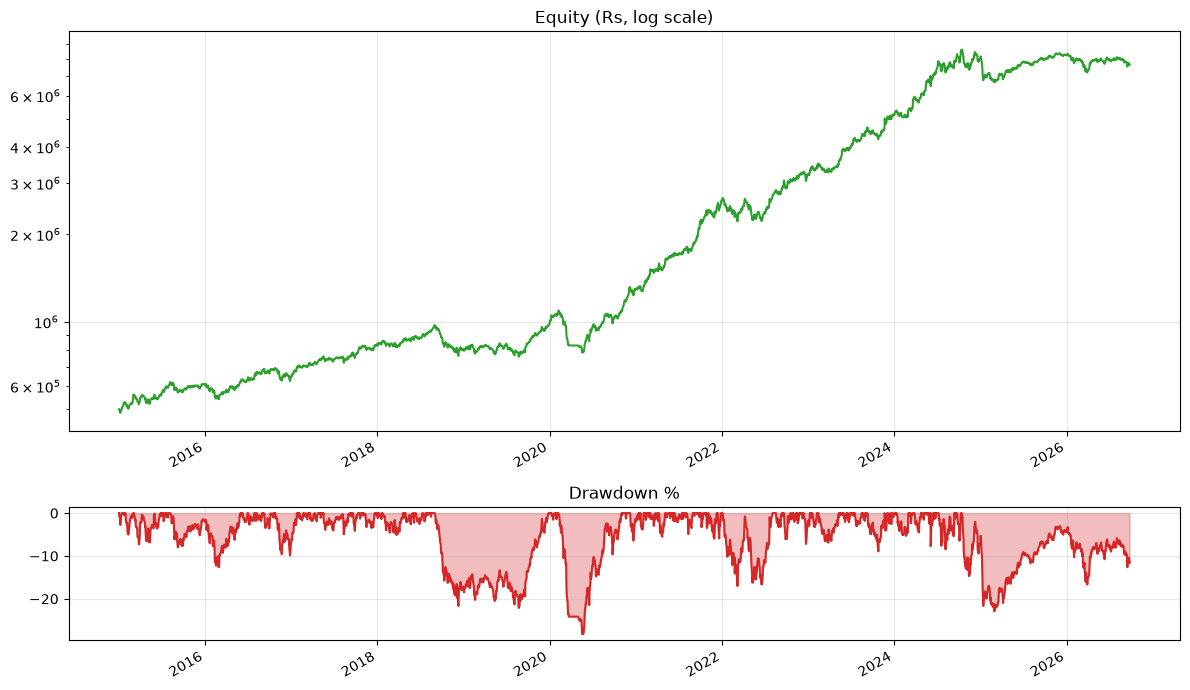

In [9]:
fig, ax = plt.subplots(2, 1, figsize=(12, 7), gridspec_kw={"height_ratios": [3, 1]})
eq.plot(ax=ax[0], color="tab:green"); ax[0].set_yscale("log"); ax[0].grid(alpha=.3); ax[0].set_title("Equity (Rs, log scale)")
dd = (eq / eq.cummax() - 1) * 100; dd.plot(ax=ax[1], color="tab:red"); ax[1].fill_between(dd.index, dd, 0, color="tab:red", alpha=.3)
ax[1].grid(alpha=.3); ax[1].set_title("Drawdown %"); plt.tight_layout(); plt.show()

In [10]:
# ============================================================
# ICHIMOKU — COMPLETE PERFORMANCE REPORT
# ============================================================

import os
import itertools
import numpy as np
import pandas as pd

INR = lambda x: f"₹{x:,.2f}"

# ------------------------------------------------------------
# BASIC PREPARATION
# ------------------------------------------------------------

trades = trades.copy()

trades["entry_date"] = pd.to_datetime(trades["entry_date"])
trades["exit_date"]  = pd.to_datetime(trades["exit_date"])

closed = trades[trades["reason"] != "OPEN"].copy()
opened = trades[trades["reason"] == "OPEN"].copy()

closed = closed.sort_values("exit_date")

# ------------------------------------------------------------
# CAPITAL / P&L
# ------------------------------------------------------------

cap0 = float(CFG["capital"])
cap1 = float(eq.iloc[-1])

yrs = (eq.index[-1] - eq.index[0]).days / 365.25

realized_pnl = closed["pnl"].sum()
unrealized_pnl = opened["pnl"].sum() if len(opened) else 0.0

net_pnl = cap1 - cap0
total_return = net_pnl / cap0

# ------------------------------------------------------------
# COMMISSION
# ------------------------------------------------------------

comm = CFG.get("commission_pct", 0) / 100

if "entry_px" in trades.columns and "qty" in trades.columns:

    entry_commission = (
        trades["qty"] *
        trades["entry_px"] *
        comm
    ).sum()

else:
    entry_commission = 0.0

exit_commission = 0.0

if "t1_px" in trades.columns and "t1_qty" in trades.columns:

    exit_commission += (
        trades["t1_qty"].fillna(0) *
        trades["t1_px"].fillna(0) *
        comm
    ).sum()

if "exit_px" in trades.columns:

    remaining_qty = (
        trades["qty"] -
        trades.get("t1_qty", pd.Series(0, index=trades.index)).fillna(0)
    )

    exit_commission += (
        remaining_qty *
        trades["exit_px"] *
        comm
    ).sum()

total_commission = entry_commission + exit_commission

# ------------------------------------------------------------
# DRAWDOWN
# ------------------------------------------------------------

peak = eq.cummax()
dd = eq / peak - 1

max_dd = dd.min()
max_dd_rs = (eq - peak).min()

trough = dd.idxmin()
peak_dt = eq.loc[:trough].idxmax()

after = eq.loc[trough:]
recovery_candidates = after[after >= peak.loc[trough]]

recovery = (
    recovery_candidates.index[0]
    if len(recovery_candidates)
    else None
)

# longest underwater period
underwater_groups = (eq < peak).astype(int)

longest_days = 0
longest_start = None
longest_end = None

current_start = None

for dt, flag in underwater_groups.items():

    if flag and current_start is None:
        current_start = dt

    elif not flag and current_start is not None:

        days = (dt - current_start).days

        if days > longest_days:
            longest_days = days
            longest_start = current_start
            longest_end = dt

        current_start = None

if current_start is not None:

    days = (eq.index[-1] - current_start).days

    if days > longest_days:
        longest_days = days
        longest_start = current_start
        longest_end = eq.index[-1]

# ------------------------------------------------------------
# RETURN / RISK METRICS
# ------------------------------------------------------------

daily_returns = eq.pct_change().dropna()

downside = daily_returns[daily_returns < 0]

if yrs > 0:
    cagr = (cap1 / cap0) ** (1 / yrs) - 1
else:
    cagr = np.nan

if daily_returns.std() > 0:

    sharpe = (
        daily_returns.mean() /
        daily_returns.std()
    ) * np.sqrt(252)

else:
    sharpe = np.nan

if len(downside) > 1 and downside.std() > 0:

    sortino = (
        daily_returns.mean() /
        downside.std()
    ) * np.sqrt(252)

else:
    sortino = np.nan

volatility = daily_returns.std() * np.sqrt(252)

if max_dd < 0:
    calmar = cagr / abs(max_dd)
else:
    calmar = np.nan

# ------------------------------------------------------------
# TRADE STATISTICS
# ------------------------------------------------------------

wins = closed[closed["pnl"] > 0]
losses = closed[closed["pnl"] <= 0]

winning_trades = len(wins)
losing_trades = len(losses)
closed_count = len(closed)

win_rate = (
    winning_trades / closed_count * 100
    if closed_count
    else 0
)

gross_profit = wins["pnl"].sum()
gross_loss = losses["pnl"].sum()

if gross_loss != 0:
    profit_factor = gross_profit / abs(gross_loss)
else:
    profit_factor = np.inf

avg_win = wins["pnl"].mean() if len(wins) else 0
avg_loss = losses["pnl"].mean() if len(losses) else 0

payoff_ratio = (
    abs(avg_win / avg_loss)
    if avg_loss != 0
    else np.nan
)

expectancy = closed["pnl"].mean() if len(closed) else 0
expectancy_pct = closed["ret_pct"].mean() if len(closed) else 0

# ------------------------------------------------------------
# CONSECUTIVE WINS / LOSSES
# ------------------------------------------------------------

def max_streak(values, target):

    best = 0
    current = 0

    for x in values:

        if x == target:
            current += 1
            best = max(best, current)

        else:
            current = 0

    return best


win_loss_sequence = (
    closed["pnl"] > 0
).tolist()

max_wins = max_streak(win_loss_sequence, True)
max_losses = max_streak(win_loss_sequence, False)

# ------------------------------------------------------------
# TARGET STATISTICS
# ------------------------------------------------------------

if "hit_target" in closed.columns:

    target_hits = int(closed["hit_target"].sum())

    target_hit_pct = (
        target_hits / len(closed) * 100
        if len(closed)
        else 0
    )

else:

    target_hits = 0
    target_hit_pct = 0

# ------------------------------------------------------------
# PERFORMANCE SUMMARY
# ------------------------------------------------------------

summary = {

    "CAPITAL": "",

    "Starting Capital":
        INR(cap0),

    "Ending Equity":
        INR(cap1),

    "Peak Equity":
        INR(eq.max()),

    "Net P&L":
        f"{INR(net_pnl)} ({total_return * 100:.2f}%)",

    "Realized P&L":
        INR(realized_pnl),

    "Unrealized P&L":
        INR(unrealized_pnl),

    "Total Commission":
        INR(total_commission),

    "RISK / RETURN": "",

    "CAGR":
        f"{cagr * 100:.2f}%",

    "Period":
        f"{eq.index[0].date()} → {eq.index[-1].date()} ({yrs:.2f} years)",

    "Max Drawdown":
        f"{max_dd * 100:.2f}%",

    "Max Drawdown ₹":
        INR(max_dd_rs),

    "Drawdown Peak":
        str(peak_dt.date()),

    "Drawdown Trough":
        str(trough.date()),

    "Recovery":
        str(recovery.date())
        if recovery is not None
        else "Not recovered",

    "Longest Underwater":
        f"{longest_days} days",

    "Current Drawdown":
        f"{dd.iloc[-1] * 100:.2f}%",

    "RISK-ADJUSTED": "",

    "Sharpe":
        f"{sharpe:.2f}",

    "Sortino":
        f"{sortino:.2f}",

    "Calmar":
        f"{calmar:.2f}",

    "Annualised Volatility":
        f"{volatility * 100:.2f}%",

    "Best Day":
        f"{daily_returns.max() * 100:.2f}%",

    "Worst Day":
        f"{daily_returns.min() * 100:.2f}%",

    "TRADES": "",

    "Total Trades":
        f"{len(trades)}",

    "Closed Trades":
        f"{len(closed)}",

    "Open Trades":
        f"{len(opened)}",

    "Winning Trades":
        f"{winning_trades}",

    "Losing Trades":
        f"{losing_trades}",

    "Win Rate":
        f"{win_rate:.2f}%",

    "Profit Factor":
        f"{profit_factor:.2f}",

    "Gross Profit":
        INR(gross_profit),

    "Gross Loss":
        INR(gross_loss),

    "Average Win":
        INR(avg_win),

    "Average Loss":
        INR(avg_loss),

    "Payoff Ratio":
        f"{payoff_ratio:.2f}",

    "Expectancy / Trade":
        INR(expectancy),

    "Expectancy %":
        f"{expectancy_pct:.2f}%",

    "Largest Win":
        INR(closed["pnl"].max())
        if len(closed) else "₹0",

    "Largest Loss":
        INR(closed["pnl"].min())
        if len(closed) else "₹0",

    "Max Consecutive Wins":
        max_wins,

    "Max Consecutive Losses":
        max_losses,

    "Average Holding Days":
        f"{closed['days'].mean():.1f}"
        if len(closed) else "0",

    "Target Hits":
        f"{target_hits} ({target_hit_pct:.2f}%)",

    "Average Positions":
        f"{n_open.mean():.2f}",

    "% Days Invested":
        f"{(n_open > 0).mean() * 100:.2f}%"
}

# ------------------------------------------------------------
# PRINT REPORT
# ------------------------------------------------------------

print("\n" + "=" * 90)
print("ICHIMOKU — COMPLETE PERFORMANCE REPORT")
print("=" * 90)

print(f"\nStrategy       : {STRATEGY}")
print(f"Trailing Stop  : {TRAIL}")
print(f"Price Mode     : {PRICE_MODE}")
print(f"Slippage Ticks : {CFG['slippage_ticks']}")
print(f"Commission     : {CFG['commission_pct']}%")

print("\n" + "-" * 90)

for key, value in summary.items():

    if value == "":
        print(f"\n{key}")

    else:
        print(f"{key:<35} {value}")

print("\n" + "=" * 90)

# ------------------------------------------------------------
# EXIT REASON
# ------------------------------------------------------------

by_reason = (
    closed
    .groupby("reason")
    .agg(
        trades=("pnl", "size"),
        net_pnl=("pnl", "sum"),
        avg_pnl=("pnl", "mean"),
        avg_return_pct=("ret_pct", "mean"),
        win_rate_pct=("pnl", lambda x: (x > 0).mean() * 100),
        avg_days=("days", "mean")
    )
    .sort_values("net_pnl", ascending=False)
    .round(2)
)

print("\nP&L BY EXIT REASON")
display(by_reason)

# ------------------------------------------------------------
# YEARLY PERFORMANCE
# ------------------------------------------------------------

year_rows = []
previous_equity = cap0

for year, equity_year in eq.groupby(eq.index.year):

    year_closed = closed[
        closed["exit_date"].dt.year == year
    ]

    start_equity = previous_equity
    end_equity = equity_year.iloc[-1]

    year_return = (
        end_equity / start_equity - 1
    ) * 100

    year_dd = (
        equity_year /
        equity_year.cummax() - 1
    ).min() * 100

    year_rows.append({
        "year": year,
        "start_equity": start_equity,
        "end_equity": end_equity,
        "pnl": end_equity - start_equity,
        "return_pct": year_return,
        "max_dd_pct": year_dd,
        "trades": len(year_closed),
        "win_rate_pct":
            (year_closed["pnl"] > 0).mean() * 100
            if len(year_closed) else np.nan,
        "realized_pnl":
            year_closed["pnl"].sum()
    })

    previous_equity = end_equity

yearly = (
    pd.DataFrame(year_rows)
    .set_index("year")
    .round(2)
)

print("\nYEAR-BY-YEAR PERFORMANCE")
display(yearly)

# ------------------------------------------------------------
# SAVE TEMP REPORT FILES
# ------------------------------------------------------------

pd.Series(
    {k: v for k, v in summary.items() if v != ""}
).to_frame("value").to_csv(
    "performance_summary.csv"
)

by_reason.to_csv("performance_by_exit_reason.csv")
yearly.to_csv("performance_yearly.csv")

print("\n✅ Performance report generated.")


ICHIMOKU — COMPLETE PERFORMANCE REPORT

Strategy       : ('price_kijun', 'strong')
Trailing Stop  : {'kind': 'pct', 'value': 30, 'be': True}
Price Mode     : raw
Slippage Ticks : 0
Commission     : 0.1%

------------------------------------------------------------------------------------------

CAPITAL
Starting Capital                    ₹500,000.00
Ending Equity                       ₹7,668,561.86
Peak Equity                         ₹8,645,703.37
Net P&L                             ₹7,168,561.86 (1433.71%)
Realized P&L                        ₹5,747,687.07
Unrealized P&L                      ₹1,414,641.08
Total Commission                    ₹65,436.17

RISK / RETURN
CAGR                                26.20%
Period                              2015-01-01 → 2026-09-25 (11.73 years)
Max Drawdown                        -28.26%
Max Drawdown ₹                      ₹-1,979,077.87
Drawdown Peak                       2020-02-07
Drawdown Trough                     2020-05-18
Recovery          

,trades,net_pnl,avg_pnl,avg_return_pct,win_rate_pct,avg_days
reason,,,,,,
TRAIL,62,7290556.35,117589.62,101.75,100.0,380.94
SL,60,-1542869.29,-25714.49,-12.26,0.0,48.92



YEAR-BY-YEAR PERFORMANCE


,start_equity,end_equity,pnl,return_pct,max_dd_pct,trades,win_rate_pct,realized_pnl
year,,,,,,,,
2015,500000.00,608116.56,108116.56,21.62,-7.97,8,37.50,9080.00
2016,608116.56,645326.77,37210.21,6.12,-11.16,17,58.82,48107.36
2017,645326.77,837070.34,191743.56,29.71,-4.93,4,25.00,-9626.91
2018,837070.34,805669.10,-31401.24,-3.75,-21.65,15,53.33,164894.62
2019,805669.10,983410.61,177741.51,22.06,-10.10,14,28.57,-61032.31
2020,983410.61,1291858.67,308448.06,31.37,-28.26,23,52.17,221582.68
2021,1291858.67,2613580.33,1321721.66,102.31,-5.97,2,100.00,261148.33
2022,2613580.33,3208182.36,594602.03,22.75,-17.00,12,41.67,11710.84
2023,3208182.36,5143541.99,1935359.63,60.33,-8.92,1,100.00,26529.05



✅ Performance report generated.


In [11]:
# ============================================================
# ICHIMOKU — SAVE COMPLETE RUN INTO NEW LATEST FOLDER
# ============================================================

import os
import json
import glob
import shutil
from datetime import datetime

# ------------------------------------------------------------
# CREATE NEW RESULT FOLDER
# ------------------------------------------------------------

ROOT_DIR = "/Users/divyang1301/STOCK_ICHIMOKU"

RESULTS_ROOT = os.path.join(
    ROOT_DIR,
    "backtest_results"
)

os.makedirs(RESULTS_ROOT, exist_ok=True)

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

strategy_name = (
    f"{STRATEGY[0]}_{STRATEGY[1]}"
)

LATEST_DIR = os.path.join(
    RESULTS_ROOT,
    f"latest_{timestamp}_{strategy_name}"
)

os.makedirs(LATEST_DIR, exist_ok=False)

print("=" * 100)
print("ICHIMOKU — SAVING COMPLETE LATEST RUN")
print("=" * 100)

print("\nFolder:")
print(LATEST_DIR)

# ------------------------------------------------------------
# 1. TRADE DATA
# ------------------------------------------------------------

trades.to_csv(
    os.path.join(LATEST_DIR, "trades.csv"),
    index=False,
    float_format="%.15g"
)

print("✓ trades.csv")

# ------------------------------------------------------------
# 2. EXECUTION LEDGER
# ------------------------------------------------------------

if "ledger" in globals():

    ledger.to_csv(
        os.path.join(LATEST_DIR, "executions.csv"),
        index=False,
        float_format="%.15g"
    )

    print("✓ executions.csv")

# ------------------------------------------------------------
# 3. EQUITY CURVE
# ------------------------------------------------------------

equity_export = pd.DataFrame({
    "equity": eq,
    "open_positions": n_open
})

equity_export.to_csv(
    os.path.join(LATEST_DIR, "equity_curve.csv"),
    index=True,
    float_format="%.15g"
)

print("✓ equity_curve.csv")

# ------------------------------------------------------------
# 4. PERFORMANCE SUMMARY
# ------------------------------------------------------------

pd.Series(
    {k: v for k, v in summary.items() if v != ""}
).to_frame("value").to_csv(
    os.path.join(
        LATEST_DIR,
        "performance_summary.csv"
    )
)

print("✓ performance_summary.csv")

# ------------------------------------------------------------
# 5. EXIT REASON
# ------------------------------------------------------------

by_reason.to_csv(
    os.path.join(
        LATEST_DIR,
        "performance_by_exit_reason.csv"
    )
)

print("✓ performance_by_exit_reason.csv")

# ------------------------------------------------------------
# 6. YEARLY PERFORMANCE
# ------------------------------------------------------------

yearly.to_csv(
    os.path.join(
        LATEST_DIR,
        "performance_yearly.csv"
    )
)

print("✓ performance_yearly.csv")

# ------------------------------------------------------------
# 7. CONFIGURATION
# ------------------------------------------------------------

configuration = {
    "run_timestamp": timestamp,

    "strategy": list(STRATEGY),

    "trailing_stop": TRAIL,

    "entry_execution": ENTRY_AT,

    "ranking": RANK_BY,

    "price_mode": PRICE_MODE,

    "data_source": DATA_SOURCE,

    "data_start": DATA_START,

    "trade_start": TRADE_START,

    "end_date": END,

    "configuration": CFG,

    "results": {
        "total_trades": int(len(trades)),
        "closed_trades": int(len(closed)),
        "open_trades": int(len(opened)),
        "final_equity": float(cap1),
        "total_pnl": float(net_pnl),
        "return_pct": float(total_return * 100),
        "cagr_pct": float(cagr * 100),
        "max_drawdown_pct": float(max_dd * 100),
        "win_rate_pct": float(win_rate),
        "profit_factor": float(profit_factor)
        if np.isfinite(profit_factor)
        else None
    }
}

with open(
    os.path.join(
        LATEST_DIR,
        "configuration.json"
    ),
    "w"
) as f:

    json.dump(
        configuration,
        f,
        indent=4,
        default=str
    )

print("✓ configuration.json")

# ------------------------------------------------------------
# 8. VALIDATION LOG
# ------------------------------------------------------------

if os.path.exists("trade_validation_log.txt"):

    shutil.copy2(
        "trade_validation_log.txt",
        os.path.join(
            LATEST_DIR,
            "trade_validation_log.txt"
        )
    )

    print("✓ trade_validation_log.txt")

# ------------------------------------------------------------
# 9. COPY EXISTING GENERATED CSV REPORTS
# ------------------------------------------------------------

# Copy additional CSV files generated by the notebook,
# while avoiding duplicate copies of files already created above.

already_saved = {
    "trades.csv",
    "executions.csv",
    "equity_curve.csv",
    "performance_summary.csv",
    "performance_by_exit_reason.csv",
    "performance_yearly.csv",
    "configuration.json"
}

for file in glob.glob("*.csv"):

    filename = os.path.basename(file)

    if filename in already_saved:
        continue

    try:

        shutil.copy2(
            file,
            os.path.join(
                LATEST_DIR,
                filename
            )
        )

        print(f"✓ {filename}")

    except Exception as e:

        print(
            f"⚠ Could not copy {filename}: {e}"
        )

# ------------------------------------------------------------
# 10. COPY PNG REPORTS
# ------------------------------------------------------------

for file in glob.glob("*.png"):

    filename = os.path.basename(file)

    try:

        shutil.copy2(
            file,
            os.path.join(
                LATEST_DIR,
                filename
            )
        )

        print(f"✓ {filename}")

    except Exception as e:

        print(
            f"⚠ Could not copy {filename}: {e}"
        )

# ------------------------------------------------------------
# 11. SAVE A README / RUN DESCRIPTION
# ------------------------------------------------------------

readme = f"""
ICHIMOKU NIFTY 200 BACKTEST
============================

Run:
{timestamp}

Strategy:
{STRATEGY}

Trailing Stop:
{TRAIL}

Entry:
{ENTRY_AT}

Ranking:
{RANK_BY}

Price Mode:
{PRICE_MODE}

Slippage Ticks:
{CFG["slippage_ticks"]}

Tick Size:
{CFG["tick_size"]}

Commission:
{CFG["commission_pct"]}%

Initial Capital:
₹{CFG["capital"]:,.2f}

Final Equity:
₹{cap1:,.2f}

Net P&L:
₹{net_pnl:,.2f}

Total Return:
{total_return * 100:.2f}%

CAGR:
{cagr * 100:.2f}%

Max Drawdown:
{max_dd * 100:.2f}%

Total Trades:
{len(trades)}

Closed Trades:
{len(closed)}

Open Trades:
{len(opened)}

IMPORTANT:
Trade execution prices are stored directly at execution time.
No entry/exit price is reconstructed from P&L or invested capital.
"""

with open(
    os.path.join(
        LATEST_DIR,
        "README.txt"
    ),
    "w"
) as f:

    f.write(readme)

print("✓ README.txt")

# ------------------------------------------------------------
# FINAL DIRECTORY LIST
# ------------------------------------------------------------

print("\n" + "=" * 100)
print("ALL RESULTS SAVED SUCCESSFULLY")
print("=" * 100)

print(f"\n📁 {LATEST_DIR}")

print("\nFiles:")

for filename in sorted(
    os.listdir(LATEST_DIR)
):

    path = os.path.join(
        LATEST_DIR,
        filename
    )

    size_kb = os.path.getsize(path) / 1024

    print(
        f"  {filename:<45} {size_kb:>10.1f} KB"
    )

print("\n" + "=" * 100)

ICHIMOKU — SAVING COMPLETE LATEST RUN

Folder:
/Users/divyang1301/STOCK_ICHIMOKU/backtest_results/latest_20260926_155250_price_kijun_strong
✓ trades.csv
✓ executions.csv
✓ equity_curve.csv
✓ performance_summary.csv
✓ performance_by_exit_reason.csv
✓ performance_yearly.csv
✓ configuration.json
✓ trade_validation_log.txt
✓ monte_carlo_summary.csv
✓ rsi2_signals_2026-09-24.csv
✓ trades_price_kijun_strong_raw.csv
✓ executions_price_kijun_strong_raw.csv
✓ monte_carlo_all_simulations.csv
✓ equity_price_kijun_strong_raw.csv
✓ exit_reason_metrics.csv
✓ yearly_returns.csv
✓ README.txt

ALL RESULTS SAVED SUCCESSFULLY

📁 /Users/divyang1301/STOCK_ICHIMOKU/backtest_results/latest_20260926_155250_price_kijun_strong

Files:
  README.txt                                           0.6 KB
  configuration.json                                   1.1 KB
  equity_curve.csv                                    87.5 KB
  equity_price_kijun_strong_raw.csv                   90.9 KB
  executions.csv                 

In [12]:
# ============================================================
# ICHIMOKU — FINAL COMPREHENSIVE PERFORMANCE METRICS
# ============================================================

import numpy as np
import pandas as pd
import math

# ------------------------------------------------------------
# PREPARE DATA
# ------------------------------------------------------------

tr = trades.copy()

tr["entry_date"] = pd.to_datetime(tr["entry_date"])
tr["exit_date"] = pd.to_datetime(tr["exit_date"])

closed = tr[tr["reason"] != "OPEN"].copy()
opened = tr[tr["reason"] == "OPEN"].copy()

closed = closed.sort_values("exit_date")

equity = eq.copy().dropna()

# Daily returns
daily_ret = equity.pct_change().dropna()

# ------------------------------------------------------------
# BASIC CAPITAL
# ------------------------------------------------------------

initial_capital = float(CFG["capital"])
final_equity = float(equity.iloc[-1])

net_pnl = final_equity - initial_capital

total_return = (
    final_equity / initial_capital - 1
)

years = (
    equity.index[-1] - equity.index[0]
).days / 365.25

cagr = (
    (final_equity / initial_capital) ** (1 / years) - 1
    if years > 0 else np.nan
)

# ------------------------------------------------------------
# EQUITY STATISTICS
# ------------------------------------------------------------

peak_equity = equity.cummax()

drawdown = equity / peak_equity - 1

max_drawdown = drawdown.min()

max_drawdown_rs = (
    equity - peak_equity
).min()

max_dd_date = drawdown.idxmin()

peak_before_dd = equity.loc[:max_dd_date].idxmax()

# Current drawdown
current_drawdown = drawdown.iloc[-1]

# ------------------------------------------------------------
# RECOVERY
# ------------------------------------------------------------

peak_value_at_dd = peak_equity.loc[max_dd_date]

post_dd = equity.loc[max_dd_date:]

recovery_candidates = post_dd[
    post_dd >= peak_value_at_dd
]

if len(recovery_candidates):

    recovery_date = recovery_candidates.index[0]

    recovery_days = (
        recovery_date - max_dd_date
    ).days

else:

    recovery_date = None
    recovery_days = None

# ------------------------------------------------------------
# UNDERWATER PERIODS
# ------------------------------------------------------------

underwater = equity < peak_equity

periods = []

start = None

for date, flag in underwater.items():

    if flag and start is None:
        start = date

    elif not flag and start is not None:

        end = date

        periods.append({
            "start": start,
            "end": end,
            "days": (end - start).days
        })

        start = None

if start is not None:

    end = equity.index[-1]

    periods.append({
        "start": start,
        "end": end,
        "days": (end - start).days
    })

if periods:

    longest_underwater = max(
        periods,
        key=lambda x: x["days"]
    )

    longest_underwater_days = longest_underwater["days"]
    longest_underwater_start = longest_underwater["start"]
    longest_underwater_end = longest_underwater["end"]

else:

    longest_underwater_days = 0
    longest_underwater_start = None
    longest_underwater_end = None

# ------------------------------------------------------------
# DAILY RISK METRICS
# ------------------------------------------------------------

daily_mean = daily_ret.mean()
daily_std = daily_ret.std()

downside = daily_ret[daily_ret < 0]

annual_volatility = (
    daily_std * np.sqrt(252)
)

sharpe = (
    daily_mean / daily_std * np.sqrt(252)
    if daily_std > 0 else np.nan
)

downside_std = downside.std()

sortino = (
    daily_mean / downside_std * np.sqrt(252)
    if len(downside) > 1 and downside_std > 0
    else np.nan
)

calmar = (
    cagr / abs(max_drawdown)
    if max_drawdown < 0
    else np.nan
)

# ------------------------------------------------------------
# DAILY BEST / WORST
# ------------------------------------------------------------

best_day = daily_ret.max()
worst_day = daily_ret.min()

best_day_date = daily_ret.idxmax()
worst_day_date = daily_ret.idxmin()

# ------------------------------------------------------------
# MONTHLY RETURNS
# ------------------------------------------------------------

monthly_equity = equity.resample("ME").last()

monthly_returns = (
    monthly_equity.pct_change().dropna()
)

best_month = (
    monthly_returns.max()
    if len(monthly_returns)
    else np.nan
)

worst_month = (
    monthly_returns.min()
    if len(monthly_returns)
    else np.nan
)

positive_months = (
    monthly_returns > 0
).sum()

negative_months = (
    monthly_returns < 0
).sum()

total_months = len(monthly_returns)

monthly_win_rate = (
    positive_months / total_months * 100
    if total_months
    else np.nan
)

# ------------------------------------------------------------
# YEARLY RETURNS
# ------------------------------------------------------------

yearly_equity = equity.resample("YE").last()

yearly_returns = (
    yearly_equity.pct_change().dropna()
)

# Include first year relative to starting capital
yearly_values = {}

previous = initial_capital

for date, value in yearly_equity.items():

    year = date.year

    yearly_values[year] = (
        value / previous - 1
    )

    previous = value

yearly_returns_full = pd.Series(yearly_values)

positive_years = (
    yearly_returns_full > 0
).sum()

negative_years = (
    yearly_returns_full < 0
).sum()

total_years = len(yearly_returns_full)

yearly_win_rate = (
    positive_years / total_years * 100
    if total_years
    else np.nan
)

best_year = yearly_returns_full.max()
worst_year = yearly_returns_full.min()

best_year_name = yearly_returns_full.idxmax()
worst_year_name = yearly_returns_full.idxmin()

# ------------------------------------------------------------
# TRADE STATISTICS
# ------------------------------------------------------------

total_trades = len(tr)
closed_trades = len(closed)
open_trades = len(opened)

wins = closed[closed["pnl"] > 0]
losses = closed[closed["pnl"] <= 0]

winning_trades = len(wins)
losing_trades = len(losses)

win_rate = (
    winning_trades / closed_trades * 100
    if closed_trades
    else 0
)

gross_profit = wins["pnl"].sum()
gross_loss = losses["pnl"].sum()

profit_factor = (
    gross_profit / abs(gross_loss)
    if gross_loss != 0
    else np.inf
)

avg_trade = (
    closed["pnl"].mean()
    if closed_trades
    else 0
)

avg_trade_return = (
    closed["ret_pct"].mean()
    if closed_trades
    else 0
)

avg_win = (
    wins["pnl"].mean()
    if winning_trades
    else 0
)

avg_loss = (
    losses["pnl"].mean()
    if losing_trades
    else 0
)

payoff_ratio = (
    abs(avg_win / avg_loss)
    if avg_loss != 0
    else np.nan
)

expectancy = avg_trade

# ------------------------------------------------------------
# MEDIAN TRADE
# ------------------------------------------------------------

median_trade = (
    closed["pnl"].median()
    if closed_trades
    else np.nan
)

median_return = (
    closed["ret_pct"].median()
    if closed_trades
    else np.nan
)

# ------------------------------------------------------------
# TRADE RETURN DISTRIBUTION
# ------------------------------------------------------------

trade_returns = closed["ret_pct"].dropna()

best_trade = (
    trade_returns.max()
    if len(trade_returns)
    else np.nan
)

worst_trade = (
    trade_returns.min()
    if len(trade_returns)
    else np.nan
)

best_trade_pnl = (
    closed["pnl"].max()
    if closed_trades
    else np.nan
)

worst_trade_pnl = (
    closed["pnl"].min()
    if closed_trades
    else np.nan
)

# ------------------------------------------------------------
# HOLDING PERIOD
# ------------------------------------------------------------

avg_holding = (
    closed["days"].mean()
    if closed_trades
    else np.nan
)

median_holding = (
    closed["days"].median()
    if closed_trades
    else np.nan
)

max_holding = (
    closed["days"].max()
    if closed_trades
    else np.nan
)

min_holding = (
    closed["days"].min()
    if closed_trades
    else np.nan
)

# ------------------------------------------------------------
# STREAKS
# ------------------------------------------------------------

result_sequence = (
    closed["pnl"] > 0
).tolist()

max_win_streak = 0
max_loss_streak = 0

current_win = 0
current_loss = 0

for result in result_sequence:

    if result:

        current_win += 1
        current_loss = 0

        max_win_streak = max(
            max_win_streak,
            current_win
        )

    else:

        current_loss += 1
        current_win = 0

        max_loss_streak = max(
            max_loss_streak,
            current_loss
        )

# ------------------------------------------------------------
# TARGET STATISTICS
# ------------------------------------------------------------

if "hit_target" in closed.columns:

    target_hits = int(
        closed["hit_target"].sum()
    )

    target_hit_rate = (
        target_hits / closed_trades * 100
        if closed_trades
        else 0
    )

else:

    target_hits = 0
    target_hit_rate = 0

# ------------------------------------------------------------
# EXIT REASONS
# ------------------------------------------------------------

exit_reason_stats = (
    closed
    .groupby("reason")
    .agg(
        trades=("pnl", "size"),
        pnl=("pnl", "sum"),
        avg_pnl=("pnl", "mean"),
        avg_return=("ret_pct", "mean"),
        win_rate=("pnl",
                  lambda x: (x > 0).mean() * 100),
        avg_days=("days", "mean")
    )
    .sort_values("pnl", ascending=False)
)

# ------------------------------------------------------------
# EXPOSURE
# ------------------------------------------------------------

avg_positions = (
    n_open.mean()
)

max_positions_used = (
    n_open.max()
)

days_in_market = (
    (n_open > 0).mean() * 100
)

days_at_max_positions = (
    (n_open >= CFG["max_positions"]).mean() * 100
)

# ------------------------------------------------------------
# PROFIT CONCENTRATION
# ------------------------------------------------------------

sorted_wins = (
    wins["pnl"]
    .sort_values(ascending=False)
)

top_1_profit_share = (
    sorted_wins.head(1).sum() /
    gross_profit * 100
    if gross_profit > 0
    else np.nan
)

top_5_profit_share = (
    sorted_wins.head(5).sum() /
    gross_profit * 100
    if gross_profit > 0
    else np.nan
)

top_10_profit_share = (
    sorted_wins.head(10).sum() /
    gross_profit * 100
    if gross_profit > 0
    else np.nan
)

# ------------------------------------------------------------
# RETURN / DRAWDOWN EFFICIENCY
# ------------------------------------------------------------

return_to_drawdown = (
    total_return / abs(max_drawdown)
    if max_drawdown < 0
    else np.nan
)

profit_to_max_dd = (
    net_pnl / abs(max_drawdown_rs)
    if max_drawdown_rs < 0
    else np.nan
)

# ------------------------------------------------------------
# PRINT FINAL REPORT
# ------------------------------------------------------------

def pct(x):
    return f"{x * 100:.2f}%"

def rs(x):
    return f"₹{x:,.2f}"

print("\n")
print("=" * 100)
print("ICHIMOKU — FINAL COMPREHENSIVE PERFORMANCE METRICS")
print("=" * 100)

print("\n" + "-" * 100)
print("1. CAPITAL & RETURN")
print("-" * 100)

print(f"Initial Capital                 {rs(initial_capital)}")
print(f"Final Equity                    {rs(final_equity)}")
print(f"Net P&L                         {rs(net_pnl)}")
print(f"Total Return                    {pct(total_return)}")
print(f"CAGR                            {pct(cagr)}")
print(f"Peak Equity                     {rs(peak_equity.max())}")

print("\n" + "-" * 100)
print("2. DRAWDOWN")
print("-" * 100)

print(f"Maximum Drawdown                {pct(max_drawdown)}")
print(f"Maximum Drawdown ₹              {rs(max_drawdown_rs)}")
print(f"DD Peak Date                    {peak_before_dd.date()}")
print(f"DD Trough Date                  {max_dd_date.date()}")
print(f"Recovery Date                   "
      f"{recovery_date.date() if recovery_date is not None else 'Not recovered'}")
print(f"Recovery Time                   "
      f"{recovery_days if recovery_days is not None else 'N/A'} days")
print(f"Current Drawdown                {pct(current_drawdown)}")
print(f"Longest Underwater              {longest_underwater_days} days")

print("\n" + "-" * 100)
print("3. RISK-ADJUSTED PERFORMANCE")
print("-" * 100)

print(f"Sharpe Ratio                    {sharpe:.3f}")
print(f"Sortino Ratio                   {sortino:.3f}")
print(f"Calmar Ratio                    {calmar:.3f}")
print(f"Annual Volatility               {pct(annual_volatility)}")
print(f"Return / Max DD                 {return_to_drawdown:.3f}")
print(f"Profit / Max DD ₹               {profit_to_max_dd:.3f}")

print("\n" + "-" * 100)
print("4. DAILY RETURN STATISTICS")
print("-" * 100)

print(f"Best Day                        {pct(best_day)}")
print(f"Best Day Date                   {best_day_date.date()}")
print(f"Worst Day                       {pct(worst_day)}")
print(f"Worst Day Date                  {worst_day_date.date()}")

print("\n" + "-" * 100)
print("5. MONTHLY CONSISTENCY")
print("-" * 100)

print(f"Positive Months                 {positive_months}")
print(f"Negative Months                 {negative_months}")
print(f"Monthly Win Rate                {monthly_win_rate:.2f}%")
print(f"Best Month                      {pct(best_month)}")
print(f"Worst Month                     {pct(worst_month)}")

print("\n" + "-" * 100)
print("6. YEARLY CONSISTENCY")
print("-" * 100)

print(f"Positive Years                  {positive_years}")
print(f"Negative Years                  {negative_years}")
print(f"Yearly Win Rate                 {yearly_win_rate:.2f}%")
print(f"Best Year                       {best_year_name}: {pct(best_year)}")
print(f"Worst Year                      {worst_year_name}: {pct(worst_year)}")

print("\n" + "-" * 100)
print("7. TRADE STATISTICS")
print("-" * 100)

print(f"Total Trades                    {total_trades}")
print(f"Closed Trades                   {closed_trades}")
print(f"Open Trades                     {open_trades}")
print(f"Winning Trades                  {winning_trades}")
print(f"Losing Trades                   {losing_trades}")
print(f"Win Rate                        {win_rate:.2f}%")
print(f"Profit Factor                   {profit_factor:.3f}")
print(f"Gross Profit                    {rs(gross_profit)}")
print(f"Gross Loss                      {rs(gross_loss)}")
print(f"Average Trade P&L               {rs(avg_trade)}")
print(f"Average Trade Return            {avg_trade_return:.2f}%")
print(f"Median Trade P&L                {rs(median_trade)}")
print(f"Median Trade Return             {median_return:.2f}%")
print(f"Average Win                     {rs(avg_win)}")
print(f"Average Loss                    {rs(avg_loss)}")
print(f"Payoff Ratio                    {payoff_ratio:.3f}")
print(f"Expectancy / Trade              {rs(expectancy)}")

print("\n" + "-" * 100)
print("8. TRADE EXTREMES")
print("-" * 100)

print(f"Largest Winning Trade           {rs(best_trade_pnl)}")
print(f"Largest Losing Trade             {rs(worst_trade_pnl)}")
print(f"Best Trade Return               {best_trade:.2f}%")
print(f"Worst Trade Return              {worst_trade:.2f}%")

print("\n" + "-" * 100)
print("9. HOLDING PERIOD")
print("-" * 100)

print(f"Average Holding                 {avg_holding:.1f} days")
print(f"Median Holding                  {median_holding:.1f} days")
print(f"Minimum Holding                 {min_holding:.0f} days")
print(f"Maximum Holding                 {max_holding:.0f} days")

print("\n" + "-" * 100)
print("10. STREAKS")
print("-" * 100)

print(f"Maximum Winning Streak          {max_win_streak}")
print(f"Maximum Losing Streak            {max_loss_streak}")

print("\n" + "-" * 100)
print("11. TARGET / EXIT")
print("-" * 100)

print(f"24% Target Hits                 {target_hits}")
print(f"Target Hit Rate                 {target_hit_rate:.2f}%")

print("\n" + exit_reason_stats.round(2).to_string())

print("\n" + "-" * 100)
print("12. PORTFOLIO EXPOSURE")
print("-" * 100)

print(f"Average Positions                {avg_positions:.2f}")
print(f"Maximum Positions Used           {max_positions_used}")
print(f"Maximum Allowed Positions        {CFG['max_positions']}")
print(f"Days Invested                    {days_in_market:.2f}%")
print(f"Days At Maximum Positions        {days_at_max_positions:.2f}%")

print("\n" + "-" * 100)
print("13. PROFIT CONCENTRATION")
print("-" * 100)

print(f"Top 1 Winner Share of Gross Profit   {top_1_profit_share:.2f}%")
print(f"Top 5 Winners Share                   {top_5_profit_share:.2f}%")
print(f"Top 10 Winners Share                  {top_10_profit_share:.2f}%")

print("\n" + "=" * 100)
print("FINAL METRICS COMPLETE")
print("=" * 100)



ICHIMOKU — FINAL COMPREHENSIVE PERFORMANCE METRICS

----------------------------------------------------------------------------------------------------
1. CAPITAL & RETURN
----------------------------------------------------------------------------------------------------
Initial Capital                 ₹500,000.00
Final Equity                    ₹7,668,561.86
Net P&L                         ₹7,168,561.86
Total Return                    1433.71%
CAGR                            26.20%
Peak Equity                     ₹8,645,703.37

----------------------------------------------------------------------------------------------------
2. DRAWDOWN
----------------------------------------------------------------------------------------------------
Maximum Drawdown                -28.26%
Maximum Drawdown ₹              ₹-1,979,077.87
DD Peak Date                    2020-02-07
DD Trough Date                  2020-05-18
Recovery Date                   2020-11-03
Recovery Time                  

ICHIMOKU — MONTE CARLO P&L BOOTSTRAP

Closed trades used       : 122
Simulations              : 10,000
Random seed              : 42
Initial capital          : ₹500,000.00

----------------------------------------------------------------------------------------------------
MONTE CARLO DISTRIBUTION
----------------------------------------------------------------------------------------------------


,Metric,P5,P10,P25,Median,P75,P90,P95
0,Final Equity,1679283.95,2172871.53,3454337.10,5828959.60,8462908.85,10884770.86,12769332.64
1,Total Return,235.86,334.57,590.87,1065.79,1592.58,2076.95,2453.87
2,CAGR,10.88,13.34,17.91,23.29,27.27,30.03,31.81
3,Maximum Drawdown,-67.72,-54.56,-37.24,-23.46,-15.05,-8.37,-5.88
4,Maximum Drawdown ₹,-549564.71,-484202.03,-384225.68,-295603.23,-228769.05,-189142.50,-162480.42
5,Maximum Winning Streak,4.00,4.00,5.00,6.00,7.00,9.00,10.00
6,Maximum Losing Streak,4.00,4.00,5.00,6.00,7.00,8.00,9.00



----------------------------------------------------------------------------------------------------
MONTE CARLO PROBABILITIES
----------------------------------------------------------------------------------------------------
Probability of finishing profitable : 99.85%
Probability of finishing below capital : 0.15%
Probability of worse DD than historical : 38.90%
Probability of DD <= -20% : 60.37%
Probability of DD <= -25% : 46.26%
Probability of DD <= -30% : 35.71%
Probability of DD <= -35% : 27.93%
Probability of DD <= -40% : 21.20%

----------------------------------------------------------------------------------------------------
HISTORICAL VS MONTE CARLO
----------------------------------------------------------------------------------------------------
Historical Final Equity       : ₹7,668,561.86
MC P5 Final Equity            : ₹1,679,283.95
MC Median Final Equity        : ₹5,828,959.60
MC P95 Final Equity           : ₹12,769,332.64

Historical Return             : 1433.71%

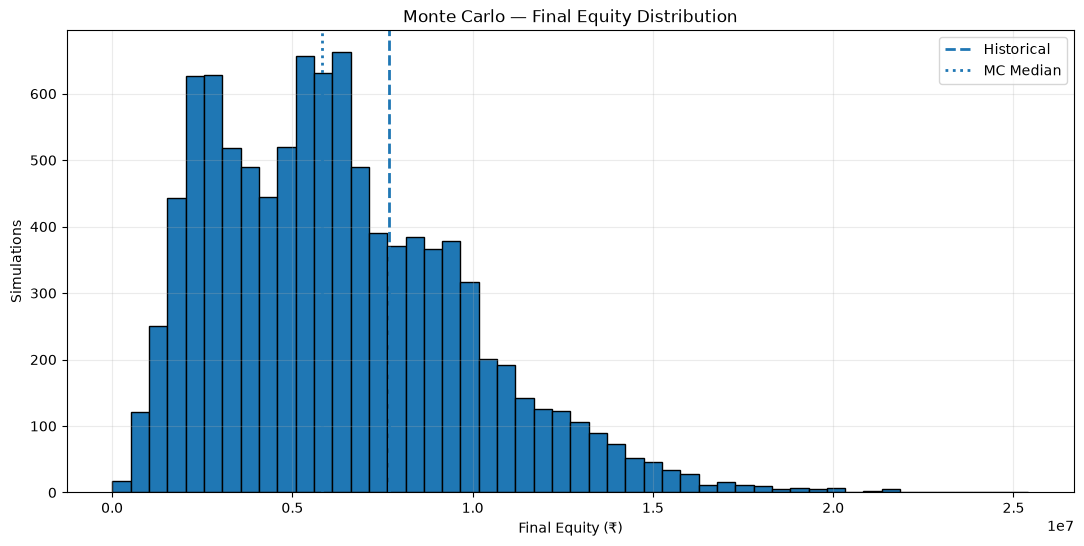

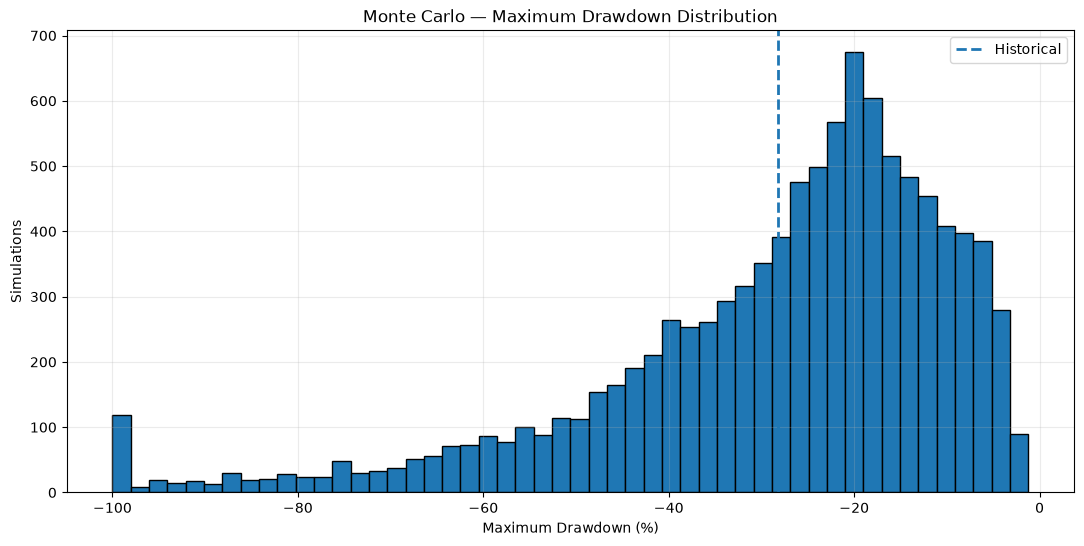

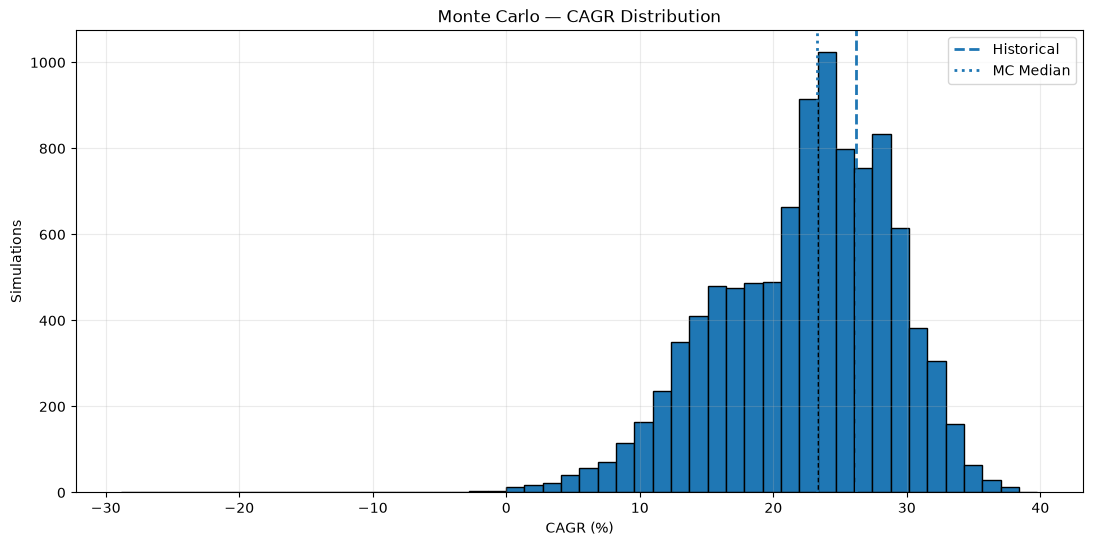


MONTE CARLO P&L BOOTSTRAP COMPLETE


In [13]:
# ============================================================
# ICHIMOKU — MONTE CARLO BOOTSTRAP
# P&L-BASED PORTFOLIO SIMULATION
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# SETTINGS
# ------------------------------------------------------------

MC_SIMULATIONS = 10000
MC_SEED = 42

rng = np.random.default_rng(MC_SEED)

# ------------------------------------------------------------
# PREPARE CLOSED TRADES
# ------------------------------------------------------------

mc_trades = closed.copy()

mc_trades = mc_trades[
    np.isfinite(mc_trades["pnl"])
].copy()

trade_pnl = mc_trades["pnl"].astype(float).values

n_trades = len(trade_pnl)

if n_trades < 10:
    raise ValueError(
        f"Only {n_trades} closed trades available. "
        "Monte Carlo requires more trades."
    )

initial_capital_mc = float(CFG["capital"])

# Historical period
mc_years = years

print("=" * 100)
print("ICHIMOKU — MONTE CARLO P&L BOOTSTRAP")
print("=" * 100)

print(f"\nClosed trades used       : {n_trades}")
print(f"Simulations              : {MC_SIMULATIONS:,}")
print(f"Random seed              : {MC_SEED}")
print(f"Initial capital          : ₹{initial_capital_mc:,.2f}")

# ------------------------------------------------------------
# STORAGE
# ------------------------------------------------------------

final_equities = np.zeros(MC_SIMULATIONS)

max_drawdowns = np.zeros(MC_SIMULATIONS)
max_drawdowns_rs = np.zeros(MC_SIMULATIONS)

max_win_streaks = np.zeros(
    MC_SIMULATIONS,
    dtype=int
)

max_loss_streaks = np.zeros(
    MC_SIMULATIONS,
    dtype=int
)

# ------------------------------------------------------------
# SIMULATION
# ------------------------------------------------------------

for sim in range(MC_SIMULATIONS):

    # Bootstrap WITH replacement.
    #
    # This is fundamentally different from merely shuffling
    # the existing trades.
    #
    # A trade can appear multiple times and another historical
    # trade may not appear at all.

    sampled_pnl = rng.choice(
        trade_pnl,
        size=n_trades,
        replace=True
    )

    # --------------------------------------------------------
    # PORTFOLIO EQUITY
    # --------------------------------------------------------

    equity_curve = np.empty(
        n_trades + 1
    )

    equity_curve[0] = initial_capital_mc

    for i in range(n_trades):

        equity_curve[i + 1] = (
            equity_curve[i] +
            sampled_pnl[i]
        )

        # Prevent impossible negative portfolio equity.
        if equity_curve[i + 1] < 0:
            equity_curve[i + 1] = 0

    # --------------------------------------------------------
    # FINAL EQUITY
    # --------------------------------------------------------

    final_equities[sim] = equity_curve[-1]

    # --------------------------------------------------------
    # DRAWDOWN
    # --------------------------------------------------------

    peaks = np.maximum.accumulate(
        equity_curve
    )

    dd_pct = np.where(
        peaks > 0,
        equity_curve / peaks - 1,
        0
    )

    dd_rs = (
        equity_curve - peaks
    )

    max_drawdowns[sim] = dd_pct.min()

    max_drawdowns_rs[sim] = dd_rs.min()

    # --------------------------------------------------------
    # STREAKS
    # --------------------------------------------------------

    current_win = 0
    current_loss = 0

    best_win = 0
    best_loss = 0

    for pnl in sampled_pnl:

        if pnl > 0:

            current_win += 1
            current_loss = 0

            best_win = max(
                best_win,
                current_win
            )

        else:

            current_loss += 1
            current_win = 0

            best_loss = max(
                best_loss,
                current_loss
            )

    max_win_streaks[sim] = best_win
    max_loss_streaks[sim] = best_loss

# ------------------------------------------------------------
# PERCENTILE HELPER
# ------------------------------------------------------------

def stats(values):

    return {
        "P5": np.percentile(values, 5),
        "P10": np.percentile(values, 10),
        "P25": np.percentile(values, 25),
        "Median": np.percentile(values, 50),
        "P75": np.percentile(values, 75),
        "P90": np.percentile(values, 90),
        "P95": np.percentile(values, 95),
    }

# ------------------------------------------------------------
# FINAL EQUITY
# ------------------------------------------------------------

equity_stats = stats(
    final_equities
)

# ------------------------------------------------------------
# TOTAL RETURN
# ------------------------------------------------------------

mc_returns = (
    final_equities /
    initial_capital_mc - 1
) * 100

return_stats = stats(
    mc_returns
)

# ------------------------------------------------------------
# CAGR
# ------------------------------------------------------------

if mc_years > 0:

    mc_cagr = np.where(
        final_equities > 0,

        (
            (
                final_equities /
                initial_capital_mc
            ) ** (1 / mc_years) - 1
        ) * 100,

        -100
    )

else:

    mc_cagr = np.full(
        MC_SIMULATIONS,
        np.nan
    )

cagr_stats = stats(
    mc_cagr
)

# ------------------------------------------------------------
# MAX DRAWDOWN
# ------------------------------------------------------------

dd_stats = stats(
    max_drawdowns * 100
)

dd_rs_stats = stats(
    max_drawdowns_rs
)

# ------------------------------------------------------------
# STREAKS
# ------------------------------------------------------------

win_streak_stats = stats(
    max_win_streaks
)

loss_streak_stats = stats(
    max_loss_streaks
)

# ------------------------------------------------------------
# PROBABILITIES
# ------------------------------------------------------------

prob_profit = (
    np.mean(
        final_equities >
        initial_capital_mc
    ) * 100
)

prob_loss = (
    np.mean(
        final_equities <
        initial_capital_mc
    ) * 100
)

# Probability of DD worse than historical
historical_dd_pct = max_drawdown * 100

prob_worse_dd = (
    np.mean(
        max_drawdowns * 100 <
        historical_dd_pct
    ) * 100
)

# DD thresholds

prob_dd_20 = (
    np.mean(max_drawdowns <= -0.20)
    * 100
)

prob_dd_25 = (
    np.mean(max_drawdowns <= -0.25)
    * 100
)

prob_dd_30 = (
    np.mean(max_drawdowns <= -0.30)
    * 100
)

prob_dd_35 = (
    np.mean(max_drawdowns <= -0.35)
    * 100
)

prob_dd_40 = (
    np.mean(max_drawdowns <= -0.40)
    * 100
)

# ------------------------------------------------------------
# SUMMARY TABLE
# ------------------------------------------------------------

mc_summary = pd.DataFrame({

    "Metric": [

        "Final Equity",
        "Total Return",
        "CAGR",
        "Maximum Drawdown",
        "Maximum Drawdown ₹",
        "Maximum Winning Streak",
        "Maximum Losing Streak"

    ],

    "P5": [

        equity_stats["P5"],
        return_stats["P5"],
        cagr_stats["P5"],
        dd_stats["P5"],
        dd_rs_stats["P5"],
        win_streak_stats["P5"],
        loss_streak_stats["P5"]

    ],

    "P10": [

        equity_stats["P10"],
        return_stats["P10"],
        cagr_stats["P10"],
        dd_stats["P10"],
        dd_rs_stats["P10"],
        win_streak_stats["P10"],
        loss_streak_stats["P10"]

    ],

    "P25": [

        equity_stats["P25"],
        return_stats["P25"],
        cagr_stats["P25"],
        dd_stats["P25"],
        dd_rs_stats["P25"],
        win_streak_stats["P25"],
        loss_streak_stats["P25"]

    ],

    "Median": [

        equity_stats["Median"],
        return_stats["Median"],
        cagr_stats["Median"],
        dd_stats["Median"],
        dd_rs_stats["Median"],
        win_streak_stats["Median"],
        loss_streak_stats["Median"]

    ],

    "P75": [

        equity_stats["P75"],
        return_stats["P75"],
        cagr_stats["P75"],
        dd_stats["P75"],
        dd_rs_stats["P75"],
        win_streak_stats["P75"],
        loss_streak_stats["P75"]

    ],

    "P90": [

        equity_stats["P90"],
        return_stats["P90"],
        cagr_stats["P90"],
        dd_stats["P90"],
        dd_rs_stats["P90"],
        win_streak_stats["P90"],
        loss_streak_stats["P90"]

    ],

    "P95": [

        equity_stats["P95"],
        return_stats["P95"],
        cagr_stats["P95"],
        dd_stats["P95"],
        dd_rs_stats["P95"],
        win_streak_stats["P95"],
        loss_streak_stats["P95"]

    ]
})

# ------------------------------------------------------------
# DISPLAY
# ------------------------------------------------------------

print("\n" + "-" * 100)
print("MONTE CARLO DISTRIBUTION")
print("-" * 100)

display(
    mc_summary.round(2)
)

# ------------------------------------------------------------
# PROBABILITY REPORT
# ------------------------------------------------------------

print("\n" + "-" * 100)
print("MONTE CARLO PROBABILITIES")
print("-" * 100)

print(
    f"Probability of finishing profitable : "
    f"{prob_profit:.2f}%"
)

print(
    f"Probability of finishing below capital : "
    f"{prob_loss:.2f}%"
)

print(
    f"Probability of worse DD than historical : "
    f"{prob_worse_dd:.2f}%"
)

print(
    f"Probability of DD <= -20% : "
    f"{prob_dd_20:.2f}%"
)

print(
    f"Probability of DD <= -25% : "
    f"{prob_dd_25:.2f}%"
)

print(
    f"Probability of DD <= -30% : "
    f"{prob_dd_30:.2f}%"
)

print(
    f"Probability of DD <= -35% : "
    f"{prob_dd_35:.2f}%"
)

print(
    f"Probability of DD <= -40% : "
    f"{prob_dd_40:.2f}%"
)

# ------------------------------------------------------------
# HISTORICAL VS MONTE CARLO
# ------------------------------------------------------------

print("\n" + "-" * 100)
print("HISTORICAL VS MONTE CARLO")
print("-" * 100)

print(
    f"Historical Final Equity       : "
    f"₹{final_equity:,.2f}"
)

print(
    f"MC P5 Final Equity            : "
    f"₹{equity_stats['P5']:,.2f}"
)

print(
    f"MC Median Final Equity        : "
    f"₹{equity_stats['Median']:,.2f}"
)

print(
    f"MC P95 Final Equity           : "
    f"₹{equity_stats['P95']:,.2f}"
)

print()

print(
    f"Historical Return             : "
    f"{total_return * 100:.2f}%"
)

print(
    f"MC Median Return              : "
    f"{return_stats['Median']:.2f}%"
)

print()

print(
    f"Historical CAGR               : "
    f"{cagr * 100:.2f}%"
)

print(
    f"MC Median CAGR                : "
    f"{cagr_stats['Median']:.2f}%"
)

print()

print(
    f"Historical Max DD             : "
    f"{historical_dd_pct:.2f}%"
)

print(
    f"MC Median Max DD              : "
    f"{dd_stats['Median']:.2f}%"
)

print(
    f"MC P95 Max DD                 : "
    f"{dd_stats['P95']:.2f}%"
)

# ------------------------------------------------------------
# HISTOGRAM — FINAL EQUITY
# ------------------------------------------------------------

plt.figure(figsize=(13, 6))

plt.hist(
    final_equities,
    bins=50,
    edgecolor="black"
)

plt.axvline(
    final_equity,
    linestyle="--",
    linewidth=2,
    label="Historical"
)

plt.axvline(
    equity_stats["Median"],
    linestyle=":",
    linewidth=2,
    label="MC Median"
)

plt.title(
    "Monte Carlo — Final Equity Distribution"
)

plt.xlabel("Final Equity (₹)")
plt.ylabel("Simulations")

plt.legend()
plt.grid(alpha=0.25)

plt.show()

# ------------------------------------------------------------
# HISTOGRAM — MAXIMUM DRAWDOWN
# ------------------------------------------------------------

plt.figure(figsize=(13, 6))

plt.hist(
    max_drawdowns * 100,
    bins=50,
    edgecolor="black"
)

plt.axvline(
    historical_dd_pct,
    linestyle="--",
    linewidth=2,
    label="Historical"
)

plt.title(
    "Monte Carlo — Maximum Drawdown Distribution"
)

plt.xlabel("Maximum Drawdown (%)")
plt.ylabel("Simulations")

plt.legend()
plt.grid(alpha=0.25)

plt.show()

# ------------------------------------------------------------
# HISTOGRAM — CAGR
# ------------------------------------------------------------

plt.figure(figsize=(13, 6))

plt.hist(
    mc_cagr,
    bins=50,
    edgecolor="black"
)

plt.axvline(
    cagr * 100,
    linestyle="--",
    linewidth=2,
    label="Historical"
)

plt.axvline(
    cagr_stats["Median"],
    linestyle=":",
    linewidth=2,
    label="MC Median"
)

plt.title(
    "Monte Carlo — CAGR Distribution"
)

plt.xlabel("CAGR (%)")
plt.ylabel("Simulations")

plt.legend()
plt.grid(alpha=0.25)

plt.show()

# ------------------------------------------------------------
# SAVE
# ------------------------------------------------------------

mc_summary.to_csv(
    "monte_carlo_summary.csv",
    index=False
)

mc_all = pd.DataFrame({

    "final_equity": final_equities,

    "total_return_pct":
        mc_returns,

    "cagr_pct":
        mc_cagr,

    "max_drawdown_pct":
        max_drawdowns * 100,

    "max_drawdown_rs":
        max_drawdowns_rs,

    "max_win_streak":
        max_win_streaks,

    "max_loss_streak":
        max_loss_streaks
})

mc_all.to_csv(
    "monte_carlo_all_simulations.csv",
    index=False
)

print("\n" + "=" * 100)
print("MONTE CARLO P&L BOOTSTRAP COMPLETE")
print("=" * 100)

In [14]:
# ============================================================
# ICHIMOKU — STORE FINAL METRICS + MONTE CARLO
# ============================================================

import os
import json
import shutil
import glob
from datetime import datetime

# ------------------------------------------------------------
# USE EXISTING LATEST_DIR IF AVAILABLE
# ------------------------------------------------------------

if "LATEST_DIR" not in globals() or not os.path.isdir(LATEST_DIR):

    RESULTS_ROOT = "/Users/divyang1301/STOCK_ICHIMOKU/backtest_results"
    os.makedirs(RESULTS_ROOT, exist_ok=True)

    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

    LATEST_DIR = os.path.join(
        RESULTS_ROOT,
        f"latest_{timestamp}_price_kijun_strong"
    )

    os.makedirs(LATEST_DIR, exist_ok=False)

print("=" * 100)
print("ICHIMOKU — STORING FINAL BASELINE")
print("=" * 100)

print(f"\nFolder:")
print(LATEST_DIR)

# ------------------------------------------------------------
# SAVE CURRENT TRADES
# ------------------------------------------------------------

trades.to_csv(
    os.path.join(LATEST_DIR, "trades.csv"),
    index=False,
    float_format="%.15g"
)

# ------------------------------------------------------------
# SAVE EQUITY
# ------------------------------------------------------------

pd.DataFrame({
    "equity": eq,
    "open_positions": n_open
}).to_csv(
    os.path.join(
        LATEST_DIR,
        "equity_curve.csv"
    ),
    float_format="%.15g"
)

# ------------------------------------------------------------
# SAVE COMPREHENSIVE METRICS
# ------------------------------------------------------------

final_metrics = {

    "initial_capital": float(initial_capital),
    "final_equity": float(final_equity),
    "net_pnl": float(net_pnl),
    "total_return_pct": float(total_return * 100),
    "cagr_pct": float(cagr * 100),

    "peak_equity": float(peak_equity.max()),

    "max_drawdown_pct": float(max_drawdown * 100),
    "max_drawdown_rs": float(max_drawdown_rs),

    "sharpe": float(sharpe),
    "sortino": float(sortino),
    "calmar": float(calmar),

    "annual_volatility_pct":
        float(annual_volatility * 100),

    "best_day_pct":
        float(best_day * 100),

    "worst_day_pct":
        float(worst_day * 100),

    "positive_months":
        int(positive_months),

    "negative_months":
        int(negative_months),

    "monthly_win_rate_pct":
        float(monthly_win_rate),

    "positive_years":
        int(positive_years),

    "negative_years":
        int(negative_years),

    "yearly_win_rate_pct":
        float(yearly_win_rate),

    "total_trades":
        int(total_trades),

    "closed_trades":
        int(closed_trades),

    "open_trades":
        int(open_trades),

    "winning_trades":
        int(winning_trades),

    "losing_trades":
        int(losing_trades),

    "win_rate_pct":
        float(win_rate),

    "profit_factor":
        float(profit_factor),

    "gross_profit":
        float(gross_profit),

    "gross_loss":
        float(gross_loss),

    "average_trade_pnl":
        float(avg_trade),

    "median_trade_pnl":
        float(median_trade),

    "expectancy":
        float(expectancy),

    "largest_win":
        float(best_trade_pnl),

    "largest_loss":
        float(worst_trade_pnl),

    "average_holding_days":
        float(avg_holding),

    "median_holding_days":
        float(median_holding),

    "max_winning_streak":
        int(max_win_streak),

    "max_losing_streak":
        int(max_loss_streak),

    "target_hits":
        int(target_hits),

    "target_hit_rate_pct":
        float(target_hit_rate),

    "average_positions":
        float(avg_positions),

    "maximum_positions":
        int(max_positions_used),

    "days_in_market_pct":
        float(days_in_market),

    "top_1_profit_share_pct":
        float(top_1_profit_share),

    "top_5_profit_share_pct":
        float(top_5_profit_share),

    "top_10_profit_share_pct":
        float(top_10_profit_share),

    "monte_carlo_simulations":
        int(MC_SIMULATIONS),

    "monte_carlo_seed":
        int(MC_SEED),

    "mc_final_equity_p5":
        float(equity_stats["P5"]),

    "mc_final_equity_median":
        float(equity_stats["Median"]),

    "mc_final_equity_p95":
        float(equity_stats["P95"]),

    "mc_return_median_pct":
        float(return_stats["Median"]),

    "mc_cagr_median_pct":
        float(cagr_stats["Median"]),

    "mc_max_dd_median_pct":
        float(dd_stats["Median"]),

    "mc_max_dd_p5_pct":
        float(dd_stats["P5"]),

    "mc_max_dd_p95_pct":
        float(dd_stats["P95"]),

    "mc_probability_profit_pct":
        float(prob_profit),

    "mc_probability_loss_pct":
        float(prob_loss),

    "mc_probability_worse_dd_pct":
        float(prob_worse_dd),

    "mc_probability_dd_20_pct":
        float(prob_dd_20),

    "mc_probability_dd_25_pct":
        float(prob_dd_25),

    "mc_probability_dd_30_pct":
        float(prob_dd_30),

    "mc_probability_dd_35_pct":
        float(prob_dd_35),

    "mc_probability_dd_40_pct":
        float(prob_dd_40)
}

with open(
    os.path.join(
        LATEST_DIR,
        "final_metrics.json"
    ),
    "w"
) as f:

    json.dump(
        final_metrics,
        f,
        indent=4
    )

# ------------------------------------------------------------
# SAVE MONTE CARLO
# ------------------------------------------------------------

mc_summary.to_csv(
    os.path.join(
        LATEST_DIR,
        "monte_carlo_summary.csv"
    ),
    index=False
)

mc_all.to_csv(
    os.path.join(
        LATEST_DIR,
        "monte_carlo_all_simulations.csv"
    ),
    index=False
)

# ------------------------------------------------------------
# SAVE EXIT REASONS
# ------------------------------------------------------------

exit_reason_stats.to_csv(
    os.path.join(
        LATEST_DIR,
        "exit_reason_metrics.csv"
    )
)

# ------------------------------------------------------------
# SAVE YEARLY RETURNS
# ------------------------------------------------------------

pd.DataFrame({
    "year": yearly_returns_full.index,
    "return_pct": yearly_returns_full.values * 100
}).to_csv(
    os.path.join(
        LATEST_DIR,
        "yearly_returns.csv"
    ),
    index=False
)

# ------------------------------------------------------------
# SAVE CONFIGURATION
# ------------------------------------------------------------

config_export = {
    "strategy": str(STRATEGY),
    "trailing_stop": TRAIL,
    "entry_execution": ENTRY_AT,
    "ranking": RANK_BY,
    "price_mode": PRICE_MODE,
    "configuration": CFG,
    "monte_carlo_simulations": MC_SIMULATIONS,
    "monte_carlo_seed": MC_SEED,
    "run_type": "FINAL_BASELINE"
}

with open(
    os.path.join(
        LATEST_DIR,
        "configuration.json"
    ),
    "w"
) as f:

    json.dump(
        config_export,
        f,
        indent=4,
        default=str
    )

# ------------------------------------------------------------
# SAVE CURRENT NOTEBOOK VARIABLES AS TEXT SUMMARY
# ------------------------------------------------------------

with open(
    os.path.join(
        LATEST_DIR,
        "BASELINE_INFO.txt"
    ),
    "w"
) as f:

    f.write(
        "ICHIMOKU FINAL BASELINE\n"
        "=======================\n\n"
        f"Strategy: {STRATEGY}\n"
        f"Trailing Stop: {TRAIL}\n"
        f"Price Mode: {PRICE_MODE}\n"
        f"Slippage Ticks: {CFG['slippage_ticks']}\n"
        f"Commission: {CFG['commission_pct']}%\n\n"
        f"Initial Capital: ₹{initial_capital:,.2f}\n"
        f"Final Equity: ₹{final_equity:,.2f}\n"
        f"Net P&L: ₹{net_pnl:,.2f}\n"
        f"CAGR: {cagr * 100:.2f}%\n"
        f"Max Drawdown: {max_drawdown * 100:.2f}%\n"
        f"Sharpe: {sharpe:.3f}\n"
        f"Sortino: {sortino:.3f}\n"
        f"Profit Factor: {profit_factor:.3f}\n"
        f"Closed Trades: {closed_trades}\n"
        f"Open Trades: {open_trades}\n\n"
        "Monte Carlo\n"
        "-----------\n"
        f"Simulations: {MC_SIMULATIONS}\n"
        f"Median Final Equity: ₹{equity_stats['Median']:,.2f}\n"
        f"P5 Final Equity: ₹{equity_stats['P5']:,.2f}\n"
        f"P95 Final Equity: ₹{equity_stats['P95']:,.2f}\n"
        f"Median CAGR: {cagr_stats['Median']:.2f}%\n"
        f"Median Max DD: {dd_stats['Median']:.2f}%\n"
        f"Probability Profit: {prob_profit:.2f}%\n"
    )

print("\n✅ Final metrics stored.")
print(f"📁 {LATEST_DIR}")

print("\nFiles:")

for f in sorted(os.listdir(LATEST_DIR)):
    print("  ✓", f)

ICHIMOKU — STORING FINAL BASELINE

Folder:
/Users/divyang1301/STOCK_ICHIMOKU/backtest_results/latest_20260926_155250_price_kijun_strong

✅ Final metrics stored.
📁 /Users/divyang1301/STOCK_ICHIMOKU/backtest_results/latest_20260926_155250_price_kijun_strong

Files:
  ✓ BASELINE_INFO.txt
  ✓ README.txt
  ✓ configuration.json
  ✓ equity_curve.csv
  ✓ equity_price_kijun_strong_raw.csv
  ✓ executions.csv
  ✓ executions_price_kijun_strong_raw.csv
  ✓ exit_reason_metrics.csv
  ✓ final_metrics.json
  ✓ monte_carlo_all_simulations.csv
  ✓ monte_carlo_summary.csv
  ✓ performance_by_exit_reason.csv
  ✓ performance_summary.csv
  ✓ performance_yearly.csv
  ✓ rsi2_signals_2026-09-24.csv
  ✓ trade_validation_log.txt
  ✓ trades.csv
  ✓ trades_price_kijun_strong_raw.csv
  ✓ yearly_returns.csv


In [16]:
# ============================================================
# ICHIMOKU — TRADE-BY-TRADE FORENSIC GUI
# ============================================================
#
# IMPORTANT:
# This GUI uses the validation information already available
# in the current notebook.
#
# It correctly separates:
#   1. ENTRY
#   2. T1 PARTIAL EXIT
#   3. FINAL EXIT
#
# Therefore a trade such as MCX can legitimately show:
#
#   Entry : 274 @ 181.77
#   T1    : 137 @ 238.46
#   Trail : 137 @ 181.77
#
# while the TOTAL trade is profitable.
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Rectangle
import ipywidgets as widgets
from IPython.display import display, clear_output


# ============================================================
# 1. CHECK TRADES
# ============================================================

if "trades" not in globals():
    raise RuntimeError(
        "❌ 'trades' DataFrame not found. Run the backtest first."
    )

if not isinstance(trades, pd.DataFrame) or trades.empty:
    raise RuntimeError(
        "❌ trades DataFrame is empty."
    )

trade_df = trades.copy()

trade_df["entry_date"] = pd.to_datetime(
    trade_df["entry_date"]
)

trade_df["exit_date"] = pd.to_datetime(
    trade_df["exit_date"]
)

trade_df = trade_df.reset_index(drop=True)

trade_df["trade_no"] = np.arange(
    1,
    len(trade_df) + 1
)

print(f"✅ Trades available: {len(trade_df)}")


# ============================================================
# 2. STOCK DATA LOADER
# ============================================================

def get_stock_dataframe(symbol):

    # --------------------------------------------------------
    # Dictionary
    # --------------------------------------------------------

    if isinstance(data, dict):

        if symbol not in data:
            raise KeyError(
                f"{symbol} not found in data dictionary."
            )

        df = data[symbol].copy()

    # --------------------------------------------------------
    # DataFrame
    # --------------------------------------------------------

    elif isinstance(data, pd.DataFrame):

        if isinstance(data.columns, pd.MultiIndex):

            if symbol in data.columns.get_level_values(0):

                df = data[symbol].copy()

            elif symbol in data.columns.get_level_values(1):

                df = data.xs(
                    symbol,
                    axis=1,
                    level=1
                ).copy()

            else:

                raise KeyError(
                    f"{symbol} not found in MultiIndex data."
                )

        else:

            df = data.copy()

    else:

        raise TypeError(
            "'data' must be a dictionary or DataFrame."
        )

    # --------------------------------------------------------
    # Date handling
    # --------------------------------------------------------

    if "Date" in df.columns:

        df["Date"] = pd.to_datetime(
            df["Date"]
        )

        df = df.set_index("Date")

    elif not isinstance(
        df.index,
        pd.DatetimeIndex
    ):

        df.index = pd.to_datetime(
            df.index
        )

    df = df.sort_index()

    return df


# ============================================================
# 3. FIND T1 INFORMATION
# ============================================================
#
# The validation output shows T1 information such as:
#
# T1 LEG 2015-03-02 qty 137 @ 238.460007
#
# If your simulator has stored T1 columns, we use them.
#
# Otherwise we derive the T1 information from the strategy:
#
# T1 price = entry_price * (1 + TP%)
#
# With your configuration:
# TP = 24%
#
# ============================================================

TP_PCT_GUI = 24.0
BOOK_FRACTION_GUI = 0.50


def get_t1_info(row):

    t1_date = None
    t1_price = None
    t1_qty = None

    # --------------------------------------------------------
    # Look for explicit T1 columns
    # --------------------------------------------------------

    date_candidates = [
        "t1_date",
        "T1_date",
        "target_date",
        "target1_date"
    ]

    price_candidates = [
        "t1_px",
        "T1_px",
        "t1_price",
        "T1_price",
        "target_px",
        "target1_px"
    ]

    qty_candidates = [
        "t1_qty",
        "T1_qty",
        "target_qty",
        "target1_qty"
    ]

    for col in date_candidates:

        if col in row.index and pd.notna(row[col]):

            t1_date = pd.Timestamp(
                row[col]
            )

            break

    for col in price_candidates:

        if col in row.index and pd.notna(row[col]):

            t1_price = float(
                row[col]
            )

            break

    for col in qty_candidates:

        if col in row.index and pd.notna(row[col]):

            t1_qty = int(
                row[col]
            )

            break

    # --------------------------------------------------------
    # If no T1 data is explicitly stored but target was hit,
    # derive target price from entry.
    # --------------------------------------------------------

    hit_target = bool(
        row.get("hit_target", False)
    )

    if hit_target:

        entry_px = float(
            row["entry_px"]
        )

        if t1_price is None:

            t1_price = (
                entry_px *
                (1 + TP_PCT_GUI / 100)
            )

        if t1_qty is None:

            qty0 = int(
                row["qty"]
            )

            t1_qty = int(
                round(
                    qty0 *
                    BOOK_FRACTION_GUI
                )
            )

            # Keep at least one share for runner
            if qty0 >= 2:

                t1_qty = min(
                    max(t1_qty, 1),
                    qty0 - 1
                )

        # ----------------------------------------------------
        # If T1 date is not stored, we search the OHLC data
        # for the first date where High >= T1 price.
        # ----------------------------------------------------

        if t1_date is None:

            try:

                symbol = row["symbol"]

                df = get_stock_dataframe(
                    symbol
                )

                entry_date = pd.Timestamp(
                    row["entry_date"]
                )

                exit_date = pd.Timestamp(
                    row["exit_date"]
                )

                window = df.loc[
                    (df.index >= entry_date) &
                    (df.index <= exit_date)
                ]

                if "High" in window.columns:

                    hit = window[
                        window["High"] >= t1_price
                    ]

                    if not hit.empty:

                        t1_date = hit.index[0]

            except Exception:

                pass

    return {
        "date": t1_date,
        "price": t1_price,
        "qty": t1_qty
    }


# ============================================================
# 4. EXIT PRICE
# ============================================================

def get_final_exit_price(row, df):

    # --------------------------------------------------------
    # Prefer explicitly stored exit price
    # --------------------------------------------------------

    for col in [
        "exit_px",
        "Exit_Price",
        "exit_price"
    ]:

        if col in row.index and pd.notna(row[col]):

            return float(row[col])

    # --------------------------------------------------------
    # For OPEN trades, last close is MTM
    # --------------------------------------------------------

    if str(row["reason"]).upper() == "OPEN":

        exit_date = pd.Timestamp(
            row["exit_date"]
        )

        rows = df.loc[
            df.index >= exit_date
        ]

        if not rows.empty:

            return float(
                rows.iloc[0]["Close"]
            )

    # --------------------------------------------------------
    # Fallback to close
    # --------------------------------------------------------

    exit_date = pd.Timestamp(
        row["exit_date"]
    )

    rows = df.loc[
        df.index >= exit_date
    ]

    if not rows.empty:

        return float(
            rows.iloc[0]["Close"]
        )

    return np.nan


# ============================================================
# 5. DROPDOWN LABEL
# ============================================================

def make_trade_label(row):

    pnl = float(
        row["pnl"]
    )

    pnl_text = (
        f"+₹{pnl:,.0f}"
        if pnl >= 0
        else
        f"-₹{abs(pnl):,.0f}"
    )

    return (
        f"Trade {int(row['trade_no']):03d} | "
        f"{row['symbol']} | "
        f"{row['entry_date'].strftime('%d-%b-%Y')} → "
        f"{row['exit_date'].strftime('%d-%b-%Y')} | "
        f"{pnl_text} | "
        f"{row['reason']}"
    )


trade_options = [
    (
        make_trade_label(row),
        int(row["trade_no"]) - 1
    )
    for _, row in trade_df.iterrows()
]


# ============================================================
# 6. DROPDOWN
# ============================================================

trade_dropdown = widgets.Dropdown(
    options=trade_options,
    description="Trade:",
    layout=widgets.Layout(
        width="1100px"
    ),
    style={
        "description_width": "70px"
    }
)


# ============================================================
# 7. OUTPUT
# ============================================================

trade_output = widgets.Output(
    layout=widgets.Layout(
        width="100%"
    )
)


# ============================================================
# 8. DRAW TRADE
# ============================================================

def show_trade(index):

    with trade_output:

        clear_output(
            wait=True
        )

        row = trade_df.iloc[index]

        symbol = str(
            row["symbol"]
        )

        entry_date = pd.Timestamp(
            row["entry_date"]
        )

        exit_date = pd.Timestamp(
            row["exit_date"]
        )

        entry_px = float(
            row["entry_px"]
        )

        qty = int(
            row["qty"]
        )

        pnl = float(
            row["pnl"]
        )

        ret_pct = float(
            row["ret_pct"]
        )

        reason = str(
            row["reason"]
        )

        # ----------------------------------------------------
        # LOAD DATA
        # ----------------------------------------------------

        try:

            df = get_stock_dataframe(
                symbol
            )

        except Exception as e:

            print(
                f"❌ Could not load {symbol}: {e}"
            )

            return

        # ----------------------------------------------------
        # FINAL EXIT
        # ----------------------------------------------------

        final_exit_px = get_final_exit_price(
            row,
            df
        )

        # ----------------------------------------------------
        # T1
        # ----------------------------------------------------

        t1 = get_t1_info(
            row
        )

        t1_date = t1["date"]
        t1_price = t1["price"]
        t1_qty = t1["qty"]

        # ----------------------------------------------------
        # CHART WINDOW
        # ----------------------------------------------------

        positions = np.where(
            df.index >= entry_date
        )[0]

        if len(positions) == 0:

            print(
                "❌ Entry date not available."
            )

            return

        entry_idx = positions[0]

        exit_positions = np.where(
            df.index >= exit_date
        )[0]

        if len(exit_positions):

            exit_idx = exit_positions[0]

        else:

            exit_idx = len(df) - 1

        start_idx = max(
            0,
            entry_idx - 100
        )

        end_idx = min(
            len(df),
            exit_idx + 30
        )

        chart_df = df.iloc[
            start_idx:end_idx
        ].copy()

        # ----------------------------------------------------
        # FIGURE
        # ----------------------------------------------------

        fig, ax = plt.subplots(
            figsize=(18, 9)
        )

        # ----------------------------------------------------
        # CANDLESTICKS
        # ----------------------------------------------------

        x = mdates.date2num(
            chart_df.index.to_pydatetime()
        )

        if len(x) > 1:

            candle_width = (
                np.median(
                    np.diff(x)
                ) * 0.65
            )

        else:

            candle_width = 0.6

        for xi, (_, r) in zip(
            x,
            chart_df.iterrows()
        ):

            o = float(r["Open"])
            h = float(r["High"])
            l = float(r["Low"])
            c = float(r["Close"])

            # Wick
            ax.plot(
                [xi, xi],
                [l, h],
                linewidth=1
            )

            # Body
            bottom = min(o, c)

            height = abs(
                c - o
            )

            if height == 0:

                height = max(
                    abs(c) * 0.0002,
                    0.01
                )

            rect = Rectangle(
                (
                    xi - candle_width / 2,
                    bottom
                ),
                candle_width,
                height,
                fill=False,
                linewidth=1
            )

            ax.add_patch(
                rect
            )

        # ----------------------------------------------------
        # INDICATORS
        # ----------------------------------------------------

        indicator_groups = [

            (
                [
                    "kijun",
                    "Kijun",
                    "Kijun_Sen"
                ],
                "Kijun"
            ),

            (
                [
                    "tenkan",
                    "Tenkan",
                    "Tenkan_Sen"
                ],
                "Tenkan"
            ),

            (
                [
                    "ema21",
                    "EMA21",
                    "EMA_21"
                ],
                "EMA21"
            ),

            (
                [
                    "ema55",
                    "EMA55",
                    "EMA_55"
                ],
                "EMA55"
            ),

            (
                [
                    "ema200",
                    "EMA200",
                    "EMA_200"
                ],
                "EMA200"
            )
        ]

        plotted = set()

        for candidates, label in indicator_groups:

            for col in candidates:

                if col in chart_df.columns:

                    if label not in plotted:

                        ax.plot(
                            chart_df.index,
                            chart_df[col],
                            linewidth=1.2,
                            label=label
                        )

                        plotted.add(
                            label
                        )

                    break

        # ----------------------------------------------------
        # CLOUD
        # ----------------------------------------------------

        cloud_top_col = None
        cloud_bottom_col = None

        for col in [
            "cloud_top",
            "Cloud_Top",
            "CloudTop",
            "Senkou_A"
        ]:

            if col in chart_df.columns:

                cloud_top_col = col
                break

        for col in [
            "cloud_bottom",
            "Cloud_Bottom",
            "CloudBottom",
            "Senkou_B"
        ]:

            if col in chart_df.columns:

                cloud_bottom_col = col
                break

        if (
            cloud_top_col is not None
            and
            cloud_bottom_col is not None
        ):

            ax.plot(
                chart_df.index,
                chart_df[cloud_top_col],
                linewidth=0.9,
                label="Cloud Top"
            )

            ax.plot(
                chart_df.index,
                chart_df[cloud_bottom_col],
                linewidth=0.9,
                label="Cloud Bottom"
            )

            ax.fill_between(
                chart_df.index,
                chart_df[
                    cloud_top_col
                ].astype(float).values,
                chart_df[
                    cloud_bottom_col
                ].astype(float).values,
                alpha=0.10
            )

        # ====================================================
        # ENTRY
        # ====================================================

        ax.axvline(
            entry_date,
            linestyle="--",
            linewidth=1.5,
            label="ENTRY"
        )

        ax.scatter(
            entry_date,
            entry_px,
            marker="^",
            s=180,
            zorder=10,
            label=(
                f"Entry "
                f"₹{entry_px:,.2f}"
            )
        )

        # Entry price line
        ax.axhline(
            entry_px,
            linestyle=":",
            linewidth=0.9
        )

        # ====================================================
        # T1 PARTIAL EXIT
        # ====================================================

        if (
            t1_date is not None
            and
            t1_price is not None
        ):

            ax.axvline(
                t1_date,
                linestyle="--",
                linewidth=1.3,
                label="T1 EXIT"
            )

            ax.scatter(
                t1_date,
                t1_price,
                marker="v",
                s=180,
                zorder=11,
                label=(
                    f"T1 "
                    f"{t1_qty} @ "
                    f"₹{t1_price:,.2f}"
                )
            )

            ax.axhline(
                t1_price,
                linestyle=":",
                linewidth=0.9
            )

        # ====================================================
        # FINAL EXIT
        # ====================================================

        if pd.notna(final_exit_px):

            ax.axvline(
                exit_date,
                linestyle="--",
                linewidth=1.5,
                label="FINAL EXIT"
            )

            ax.scatter(
                exit_date,
                final_exit_px,
                marker="v",
                s=180,
                zorder=12,
                label=(
                    f"Final Exit "
                    f"₹{final_exit_px:,.2f}"
                )
            )

            ax.axhline(
                final_exit_px,
                linestyle=":",
                linewidth=0.9
            )

        # ====================================================
        # TITLE
        # ====================================================

        pnl_sign = (
            "+"
            if pnl >= 0
            else ""
        )

        title = (
            f"TRADE #{int(row['trade_no'])} — {symbol}\n"
            f"{entry_date.strftime('%d-%b-%Y')} → "
            f"{exit_date.strftime('%d-%b-%Y')}   |   "
            f"P&L: {pnl_sign}₹{pnl:,.2f}   |   "
            f"Return: {ret_pct:+.2f}%   |   "
            f"Exit: {reason}"
        )

        ax.set_title(
            title,
            fontsize=14,
            fontweight="bold"
        )

        ax.set_ylabel(
            "Price"
        )

        ax.grid(
            True,
            alpha=0.20
        )

        ax.legend(
            loc="best",
            ncol=3
        )

        ax.xaxis.set_major_formatter(
            mdates.DateFormatter(
                "%d-%b-%y"
            )
        )

        fig.autofmt_xdate()

        plt.tight_layout()

        plt.show()

        # ====================================================
        # TRADE SUMMARY
        # ====================================================

        t1_pnl = None
        final_leg_qty = qty

        if (
            t1_price is not None
            and
            t1_qty is not None
        ):

            t1_pnl = (
                t1_qty *
                (t1_price - entry_px)
            )

            final_leg_qty = (
                qty - t1_qty
            )

        final_leg_pnl = None

        if (
            final_exit_px is not None
            and
            final_leg_qty is not None
        ):

            final_leg_pnl = (
                final_leg_qty *
                (final_exit_px - entry_px)
            )

        # ----------------------------------------------------
        # INFORMATION TABLE
        # ----------------------------------------------------

        info_rows = [

            ("Trade #",
             int(row["trade_no"])),

            ("Symbol",
             symbol),

            ("Entry Date",
             entry_date.strftime(
                 "%d-%b-%Y"
             )),

            ("Entry Price",
             f"₹{entry_px:,.2f}"),

            ("Initial Quantity",
             f"{qty:,}"),

            (
                "T1 Date",
                (
                    t1_date.strftime(
                        "%d-%b-%Y"
                    )
                    if t1_date is not None
                    else "N/A"
                )
            ),

            (
                "T1 Quantity",
                (
                    f"{t1_qty:,}"
                    if t1_qty is not None
                    else "N/A"
                )
            ),

            (
                "T1 Price",
                (
                    f"₹{t1_price:,.2f}"
                    if t1_price is not None
                    else "N/A"
                )
            ),

            (
                "T1 Gross P&L",
                (
                    f"₹{t1_pnl:,.2f}"
                    if t1_pnl is not None
                    else "N/A"
                )
            ),

            (
                "Final Exit Date",
                exit_date.strftime(
                    "%d-%b-%Y"
                )
            ),

            (
                "Final Exit Quantity",
                f"{final_leg_qty:,}"
            ),

            (
                "Final Exit Price",
                (
                    f"₹{final_exit_px:,.2f}"
                    if pd.notna(final_exit_px)
                    else "N/A"
                )
            ),

            (
                "Final Leg Gross P&L",
                (
                    f"₹{final_leg_pnl:,.2f}"
                    if final_leg_pnl is not None
                    else "N/A"
                )
            ),

            (
                "TOTAL P&L",
                f"₹{pnl:,.2f}"
            ),

            (
                "TOTAL RETURN",
                f"{ret_pct:+.2f}%"
            ),

            (
                "Holding Days",
                row.get(
                    "days",
                    "N/A"
                )
            ),

            (
                "Exit Reason",
                reason
            ),

            (
                "Target Hit",
                row.get(
                    "hit_target",
                    "N/A"
                )
            )
        ]

        info = pd.DataFrame(
            info_rows,
            columns=[
                "Metric",
                "Value"
            ]
        )

        display(
            info
        )

        # ====================================================
        # EXECUTION SUMMARY
        # ====================================================

        print(
            "\n"
            "============================================================\n"
            f"TRADE #{int(row['trade_no'])} EXECUTION BREAKDOWN\n"
            "============================================================"
        )

        print(
            f"ENTRY  : {qty:,} shares @ ₹{entry_px:,.6f}"
        )

        if t1_price is not None:

            print(
                f"T1     : {t1_qty:,} shares @ "
                f"₹{t1_price:,.6f} "
                f"on {t1_date.strftime('%d-%b-%Y') if t1_date else 'N/A'}"
            )

        if pd.notna(final_exit_px):

            print(
                f"FINAL  : {final_leg_qty:,} shares @ "
                f"₹{final_exit_px:,.6f} "
                f"on {exit_date.strftime('%d-%b-%Y')}"
            )

        print(
            f"TOTAL  : ₹{pnl:,.2f} "
            f"({ret_pct:+.2f}%)"
        )

        print(
            "============================================================"
        )


# ============================================================
# 9. CALLBACK
# ============================================================

def on_trade_change(change):

    if change["name"] == "value":

        show_trade(
            change["new"]
        )


trade_dropdown.observe(
    on_trade_change,
    names="value"
)


# ============================================================
# 10. DISPLAY GUI
# ============================================================

display(
    widgets.VBox([
        widgets.HTML(
            """
            <h2>📊 Ichimoku — Trade Forensic Viewer</h2>
            <p>
            Select any trade to inspect the complete execution:
            Entry → T1 Partial Exit → Final Exit.
            </p>
            """
        ),

        trade_dropdown,

        trade_output
    ])
)


# ============================================================
# 11. SHOW FIRST TRADE
# ============================================================

show_trade(0)

✅ Trades available: 132


In [18]:
# ============================================================
# ICHIMOKU — TRADE GUI
# ENTRY + T1 P&L + FINAL EXIT P&L + TOTAL P&L
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output

# ------------------------------------------------------------
# BASIC CHECK
# ------------------------------------------------------------

if "trades" not in globals():
    raise RuntimeError("❌ 'trades' DataFrame not found.")

trades_gui = trades.copy()

if trades_gui.empty:
    raise RuntimeError("❌ No trades available.")

trades_gui["entry_date"] = pd.to_datetime(trades_gui["entry_date"])
trades_gui["exit_date"] = pd.to_datetime(trades_gui["exit_date"])

# ------------------------------------------------------------
# SYMBOL LIST
# ------------------------------------------------------------

symbols = sorted(trades_gui["symbol"].dropna().unique().tolist())

symbol_dropdown = widgets.Dropdown(
    options=symbols,
    description="Stock:",
    layout=widgets.Layout(width="350px")
)

trade_dropdown = widgets.Dropdown(
    description="Trade:",
    layout=widgets.Layout(width="450px")
)

output = widgets.Output()


# ============================================================
# DATA ACCESS
# ============================================================

def get_stock_dataframe(symbol):

    # -----------------------------------------
    # CASE 1: data is dictionary
    # -----------------------------------------
    if isinstance(data, dict):

        if symbol in data:
            df = data[symbol].copy()

        else:
            # case-insensitive search
            match = None

            for k in data.keys():
                if str(k).upper() == str(symbol).upper():
                    match = k
                    break

            if match is None:
                return None

            df = data[match].copy()

    # -----------------------------------------
    # CASE 2: dataframe
    # -----------------------------------------
    elif isinstance(data, pd.DataFrame):

        df = data.copy()

        # MultiIndex columns
        if isinstance(df.columns, pd.MultiIndex):

            try:
                if symbol in df.columns.get_level_values(0):
                    df = df[symbol].copy()
                elif symbol in df.columns.get_level_values(1):
                    df = df.xs(symbol, axis=1, level=1).copy()
                else:
                    return None

            except Exception:
                return None

    else:
        return None

    # ------------------------------------------------
    # Normalize columns
    # ------------------------------------------------

    df.columns = [str(c).strip() for c in df.columns]

    if "Date" in df.columns:
        df["Date"] = pd.to_datetime(df["Date"])
        df = df.set_index("Date")

    elif not isinstance(df.index, pd.DatetimeIndex):
        try:
            df.index = pd.to_datetime(df.index)
        except:
            pass

    return df.sort_index()


# ============================================================
# FIND T1 INFORMATION
# ============================================================

def get_t1_info(row, df):

    """
    Returns:

        t1_exists
        t1_date
        t1_qty
        t1_price
        t1_pnl

    Uses explicit T1 fields if available.

    Otherwise reconstructs T1 using:

        TP = entry_price * 1.24

    and actual simulator-style fill:

        fill = max(Open, TP)

    on the first bar where High >= TP.
    """

    entry_date = pd.Timestamp(row["entry_date"])
    exit_date = pd.Timestamp(row["exit_date"])

    entry_px = float(row["entry_px"])
    qty0 = int(row["qty"])

    # --------------------------------------------------------
    # Explicit T1 columns
    # --------------------------------------------------------

    possible_date_cols = [
        "t1_date",
        "target_date",
        "target1_date"
    ]

    possible_px_cols = [
        "t1_px",
        "t1_price",
        "target_price",
        "target1_price"
    ]

    possible_qty_cols = [
        "t1_qty",
        "target_qty",
        "target1_qty"
    ]

    t1_date = None
    t1_price = None
    t1_qty = None

    for c in possible_date_cols:
        if c in row.index and pd.notna(row[c]):
            t1_date = pd.Timestamp(row[c])
            break

    for c in possible_px_cols:
        if c in row.index and pd.notna(row[c]):
            t1_price = float(row[c])
            break

    for c in possible_qty_cols:
        if c in row.index and pd.notna(row[c]):
            t1_qty = int(row[c])
            break

    # --------------------------------------------------------
    # If explicit T1 information exists
    # --------------------------------------------------------

    if t1_date is not None and t1_price is not None:

        if t1_qty is None:
            t1_qty = int(round(qty0 * 0.50))

        t1_pnl = (t1_price - entry_px) * t1_qty

        return True, t1_date, t1_qty, t1_price, t1_pnl

    # --------------------------------------------------------
    # No T1 if target not hit
    # --------------------------------------------------------

    hit_target = bool(row.get("hit_target", False))

    if not hit_target:
        return False, None, 0, np.nan, 0.0

    # --------------------------------------------------------
    # Reconstruct target
    # --------------------------------------------------------

    TP_PCT = 24.0

    tp_px = entry_px * (1 + TP_PCT / 100)

    # 50% partial booking
    t1_qty = int(round(qty0 * 0.50))

    if qty0 >= 2:
        t1_qty = min(max(t1_qty, 1), qty0 - 1)
    else:
        return False, None, 0, np.nan, 0.0

    # --------------------------------------------------------
    # Search first bar where target was reached
    # --------------------------------------------------------

    search_end = exit_date

    if search_end < entry_date:
        return False, None, 0, np.nan, 0.0

    sub = df.loc[
        (df.index >= entry_date) &
        (df.index <= search_end)
    ].copy()

    if sub.empty:
        return False, None, 0, np.nan, 0.0

    for dt, bar in sub.iterrows():

        try:
            high = float(bar["High"])
            opn = float(bar["Open"])
        except:
            continue

        if high >= tp_px:

            # Same execution logic as simulator:
            # fill = max(open, TP)
            fill_px = max(opn, tp_px)

            t1_pnl = (fill_px - entry_px) * t1_qty

            return True, dt, t1_qty, fill_px, t1_pnl

    return False, None, 0, np.nan, 0.0


# ============================================================
# FINAL EXIT P&L
# ============================================================

def get_final_exit_info(row, t1_exists, t1_qty):

    entry_px = float(row["entry_px"])
    qty0 = int(row["qty"])

    exit_px = float(row.get("exit_px", np.nan))

    if np.isnan(exit_px):
        exit_px = entry_px

    # --------------------------------------------------------
    # Remaining quantity
    # --------------------------------------------------------

    if t1_exists:
        final_qty = qty0 - t1_qty
    else:
        final_qty = qty0

    # --------------------------------------------------------
    # OPEN positions
    # --------------------------------------------------------

    reason = str(row.get("reason", ""))

    if reason == "OPEN":

        final_pnl = (exit_px - entry_px) * final_qty

    else:

        final_pnl = (exit_px - entry_px) * final_qty

    return final_qty, exit_px, final_pnl


# ============================================================
# TOTAL P&L
# ============================================================

def calculate_trade_pnl(row, t1_pnl, final_pnl):

    total_pnl = t1_pnl + final_pnl

    invested = float(row["invested"])

    total_return = (
        total_pnl / invested * 100
        if invested != 0
        else np.nan
    )

    return total_pnl, total_return


# ============================================================
# UPDATE TRADE DROPDOWN
# ============================================================

def update_trade_dropdown(*args):

    symbol = symbol_dropdown.value

    subset = trades_gui[
        trades_gui["symbol"] == symbol
    ].copy()

    options = []

    for idx, row in subset.iterrows():

        label = (
            f"Trade #{idx + 1} | "
            f"{row['entry_date'].strftime('%d-%b-%Y')} → "
            f"{row['exit_date'].strftime('%d-%b-%Y')} | "
            f"{row['reason']} | "
            f"P&L ₹{row['pnl']:,.0f}"
        )

        options.append((label, idx))

    trade_dropdown.options = options

    if options:
        trade_dropdown.value = options[0][1]


symbol_dropdown.observe(
    update_trade_dropdown,
    names="value"
)


# ============================================================
# DISPLAY TRADE
# ============================================================

def show_trade(change=None):

    with output:

        clear_output(wait=True)

        if trade_dropdown.value is None:
            return

        idx = trade_dropdown.value

        row = trades_gui.loc[idx]

        symbol = row["symbol"]

        df = get_stock_dataframe(symbol)

        # ----------------------------------------------------
        # ENTRY
        # ----------------------------------------------------

        entry_date = pd.Timestamp(row["entry_date"])
        entry_px = float(row["entry_px"])
        qty0 = int(row["qty"])

        invested = float(row["invested"])

        # ----------------------------------------------------
        # T1
        # ----------------------------------------------------

        if df is not None:

            (
                t1_exists,
                t1_date,
                t1_qty,
                t1_price,
                t1_pnl
            ) = get_t1_info(row, df)

        else:

            t1_exists = False
            t1_date = None
            t1_qty = 0
            t1_price = np.nan
            t1_pnl = 0.0

        # ----------------------------------------------------
        # FINAL EXIT
        # ----------------------------------------------------

        final_qty, final_price, final_pnl = get_final_exit_info(
            row,
            t1_exists,
            t1_qty
        )

        # ----------------------------------------------------
        # TOTAL
        # ----------------------------------------------------

        total_pnl, total_return = calculate_trade_pnl(
            row,
            t1_pnl,
            final_pnl
        )

        # ====================================================
        # HEADER
        # ====================================================

        print("=" * 90)
        print(f"{symbol} — Trade #{idx + 1}")
        print("=" * 90)

        # ====================================================
        # ENTRY
        # ====================================================

        print("\nENTRY")
        print("-" * 90)

        print(f"Date       : {entry_date.strftime('%d-%b-%Y')}")
        print(f"Quantity   : {qty0:,}")
        print(f"Price      : ₹{entry_px:,.6f}")
        print(f"Investment : ₹{invested:,.2f}")

        # ====================================================
        # T1
        # ====================================================

        if t1_exists:

            print("\nT1 — 50% BOOK")
            print("-" * 90)

            print(f"Date       : {t1_date.strftime('%d-%b-%Y')}")
            print(f"Quantity   : {t1_qty:,}")
            print(f"Price      : ₹{t1_price:,.6f}")

            print(
                f"T1 P&L     : "
                f"{'+' if t1_pnl >= 0 else ''}"
                f"₹{t1_pnl:,.2f}"
            )

        else:

            print("\nT1")
            print("-" * 90)
            print("No partial target booking")

        # ====================================================
        # FINAL EXIT
        # ====================================================

        print("\nFINAL EXIT")
        print("-" * 90)

        print(f"Date       : {row['exit_date'].strftime('%d-%b-%Y')}")
        print(f"Quantity   : {final_qty:,}")
        print(f"Price      : ₹{final_price:,.6f}")

        print(
            f"Final P&L  : "
            f"{'+' if final_pnl >= 0 else ''}"
            f"₹{final_pnl:,.2f}"
        )

        print(f"Exit Reason: {row['reason']}")

        # ====================================================
        # TOTAL
        # ====================================================

        print("\nTOTAL TRADE")
        print("-" * 90)

        print(
            f"Total P&L  : "
            f"{'+' if total_pnl >= 0 else ''}"
            f"₹{total_pnl:,.2f}"
        )

        print(f"Return     : {total_return:+.2f}%")
        print(f"Holding    : {row['days']} days")

        print("=" * 90)

        # ====================================================
        # P&L BREAKDOWN TABLE
        # ====================================================

        breakdown = pd.DataFrame({

            "Leg": [
                "T1",
                "Final Exit",
                "TOTAL"
            ],

            "Date": [
                t1_date.strftime("%d-%b-%Y")
                if t1_exists else "-",

                row["exit_date"].strftime("%d-%b-%Y"),

                ""
            ],

            "Qty": [
                t1_qty if t1_exists else 0,
                final_qty,
                qty0
            ],

            "Price": [
                t1_price if t1_exists else np.nan,
                final_price,
                np.nan
            ],

            "P&L": [
                t1_pnl,
                final_pnl,
                total_pnl
            ]
        })

        display(breakdown.style.format({
            "Price": "₹{:,.4f}",
            "P&L": "₹{:,.2f}"
        }))

        # ====================================================
        # CHART
        # ====================================================

        if df is None:
            print("\n⚠️ OHLC data not available for chart.")
            return

        start = entry_date - pd.Timedelta(days=30)

        exit_date = pd.Timestamp(row["exit_date"])

        end = exit_date + pd.Timedelta(days=30)

        chart_df = df.loc[
            (df.index >= start) &
            (df.index <= end)
        ].copy()

        if chart_df.empty:
            return

        # ----------------------------------------------------
        # PRICE
        # ----------------------------------------------------

        plt.figure(figsize=(16, 7))

        plt.plot(
            chart_df.index,
            chart_df["Close"],
            label="Close"
        )

        # ----------------------------------------------------
        # KIJUN
        # ----------------------------------------------------

        for col, label in [
            ("kijun", "Kijun"),
            ("Kijun", "Kijun"),
            ("tenkan", "Tenkan"),
            ("Tenkan", "Tenkan"),
            ("EMA21", "EMA21"),
            ("EMA55", "EMA55"),
            ("EMA200", "EMA200"),
        ]:

            if col in chart_df.columns:

                plt.plot(
                    chart_df.index,
                    chart_df[col],
                    label=label,
                    alpha=0.7
                )

        # ----------------------------------------------------
        # ENTRY
        # ----------------------------------------------------

        plt.scatter(
            entry_date,
            entry_px,
            marker="^",
            s=140,
            label="ENTRY",
            zorder=5
        )

        # ----------------------------------------------------
        # T1
        # ----------------------------------------------------

        if t1_exists:

            plt.scatter(
                t1_date,
                t1_price,
                marker="o",
                s=140,
                label=f"T1 +₹{t1_pnl:,.0f}",
                zorder=6
            )

        # ----------------------------------------------------
        # FINAL EXIT
        # ----------------------------------------------------

        plt.scatter(
            exit_date,
            final_price,
            marker="v",
            s=140,
            label=f"FINAL ₹{final_pnl:,.0f}",
            zorder=5
        )

        # ----------------------------------------------------
        # TITLE
        # ----------------------------------------------------

        plt.title(
            f"{symbol} | "
            f"Total P&L ₹{total_pnl:,.0f} | "
            f"Return {total_return:+.2f}%"
        )

        plt.xlabel("Date")
        plt.ylabel("Price")

        plt.grid(alpha=0.25)
        plt.legend()

        plt.tight_layout()
        plt.show()


trade_dropdown.observe(
    show_trade,
    names="value"
)


# ============================================================
# INITIALIZE
# ============================================================

display(
    widgets.VBox([
        widgets.HBox([
            symbol_dropdown,
            trade_dropdown
        ]),
        output
    ])
)

update_trade_dropdown()
show_trade()

In [19]:
# ============================================================
# ICHIMOKU — TARGET-MISS DIAGNOSTIC (any symbol/trade)
# ============================================================
import numpy as np
import pandas as pd

SYMBOL = "BHARATFORG"   # change to check any other trade/symbol

sym_trades = trades[trades["symbol"] == SYMBOL].copy()
if sym_trades.empty:
    raise ValueError(f"No trades found for {SYMBOL}")

def get_raw_df(symbol):
    if isinstance(data, dict):
        if symbol in data:
            return data[symbol].copy()
        for k in data.keys():
            if str(k).upper() == symbol.upper():
                return data[k].copy()
        raise KeyError(symbol)
    if isinstance(data, pd.DataFrame):
        df = data.copy()
        if isinstance(df.columns, pd.MultiIndex):
            if symbol in df.columns.get_level_values(0):
                return df[symbol].copy()
            elif symbol in df.columns.get_level_values(1):
                return df.xs(symbol, axis=1, level=1).copy()
        return df
    raise TypeError("Unrecognized 'data' structure")

raw = get_raw_df(SYMBOL)
if "Date" in raw.columns:
    raw["Date"] = pd.to_datetime(raw["Date"]); raw = raw.set_index("Date")
raw = raw.sort_index()

for _, row in sym_trades.iterrows():
    entry_date = pd.Timestamp(row["entry_date"])
    exit_date  = pd.Timestamp(row["exit_date"])
    entry_px   = float(row["entry_px"])
    tp_px      = entry_px * (1 + CFG["tp_pct"] / 100)
    sl_px      = entry_px * (1 - CFG["sl_pct"] / 100)

    print("=" * 100)
    print(f"{SYMBOL}  entry {entry_date.date()} @ {entry_px:.6f}  "
          f"-> exit {exit_date.date()} (reason={row['reason']}, hit_target={row['hit_target']})")
    print(f"SL level  : {sl_px:.4f}    TP (T1) level : {tp_px:.4f}")
    print("-" * 100)

    if entry_date in raw.index:
        eb = raw.loc[entry_date]
        print(f"Entry bar (raw)  O/H/L/C : {eb['Open']:.4f} / {eb['High']:.4f} / "
              f"{eb['Low']:.4f} / {eb['Close']:.4f}")
    else:
        print("⚠ entry_date not found in raw data index for this symbol.")

    window = raw.loc[(raw.index > entry_date) & (raw.index <= exit_date)]
    print(f"\nTrading days held           : {len(window)}")
    print(f"Raw max High in window      : {window['High'].max():.4f}   (target {tp_px:.4f})")
    print(f"Raw min Low  in window      : {window['Low'].min():.4f}    (SL {sl_px:.4f})")

    tp_hits = window[window["High"] >= tp_px]
    sl_hits = window[window["Low"] <= sl_px]
    print(f"Days High >= target         : {len(tp_hits)}")
    print(f"Days Low  <= stop-loss       : {len(sl_hits)}")

    top5 = window.sort_values("High", ascending=False).head(5)
    print("\nHighest 5 days actually reached (raw data):")
    for d, r in top5.iterrows():
        gap_pct = (tp_px / r["High"] - 1) * 100
        print(f"   {d.date()}   High={r['High']:>10.4f}   "
              f"({gap_pct:+.2f}% still needed to reach target)")

    print("-" * 100)
    if len(tp_hits) == 0:
        max_h = window['High'].max()
        pct_of_entry = (max_h / entry_px - 1) * 100
        print(f"VERDICT: NOT A BUG. Over the full {len(window)}-day holding window, "
              f"{SYMBOL}'s raw High never reached the 24% target (best it did was "
              f"+{pct_of_entry:.2f}% on {top5.index[0].date()}, vs +24.00% needed). "
              f"hit_target=False / reason=OPEN is the correct, expected outcome.")
    else:
        print(f"VERDICT: The raw data DOES show {len(tp_hits)} day(s) where High crossed "
              f"the target, first on {tp_hits.index[0].date()} "
              f"(High={tp_hits.iloc[0]['High']:.4f}), yet the trade is recorded as "
              f"hit_target=False. THIS IS A REAL BUG in simulate()'s day-loop for this "
              f"symbol/date — check whether that date is NaN in "
              f"P['High'][:, P['syms'].index('{SYMBOL}')] (a build_panel() reindex gap) "
              f"vs. some other logic issue.")
    print("=" * 100)

BHARATFORG  entry 2026-06-10 @ 1949.199951  -> exit 2026-09-25 (reason=OPEN, hit_target=False)
SL level  : 1715.2960    TP (T1) level : 2417.0079
----------------------------------------------------------------------------------------------------
Entry bar (raw)  O/H/L/C : 1925.4000 / 1975.4000 / 1877.0000 / 1949.2000

Trading days held           : 77
Raw max High in window      : 2295.0000   (target 2417.0079)
Raw min Low  in window      : 1850.4000    (SL 1715.2960)
Days High >= target         : 0
Days Low  <= stop-loss       : 0

Highest 5 days actually reached (raw data):
   2026-08-10   High= 2295.0000   (+5.32% still needed to reach target)
   2026-08-07   High= 2270.0000   (+6.48% still needed to reach target)
   2026-06-29   High= 2238.0000   (+8.00% still needed to reach target)
   2026-08-03   High= 2232.5000   (+8.26% still needed to reach target)
   2026-08-05   High= 2229.8000   (+8.40% still needed to reach target)
---------------------------------------------------------

done: baseline
done: ROC26 >= 0%
done: ROC26 >= 10%
done: ROC26 >= 20%
done: ROC26 >= 26%
done: ROC26 >= 30%
done: ROC26 >= 40%


,signals kept %,CAGR %,max DD %,Calmar,Sharpe,trades,win %,profit factor,avg slots used,CAGR 2015-20 %,CAGR 2021-now %
filter,,,,,,,,,,,
baseline,100.0,26.20,-28.26,0.93,1.56,132,52.3,5.25,9.86,17.15,36.45
ROC26 >= 0%,80.5,24.57,-22.41,1.10,1.47,130,50.0,5.31,9.87,12.13,39.08
ROC26 >= 10%,9.8,21.97,-28.89,0.76,1.28,169,45.0,3.42,9.35,10.29,35.53
ROC26 >= 20%,1.2,20.41,-25.49,0.80,1.44,97,49.5,4.96,3.61,11.18,30.65
ROC26 >= 26%,0.4,17.41,-24.98,0.70,1.23,40,40.0,7.90,1.69,6.13,30.37
ROC26 >= 30%,0.2,16.88,-23.46,0.72,1.27,21,52.4,14.48,1.36,4.52,31.26
ROC26 >= 40%,0.0,0.09,-5.44,0.02,0.09,4,25.0,1.27,0.04,0.37,-0.21


random 20/20
ROC26 >= 26% Calmar 0.70 beats 100% of random skips (random median 0.28)
FAIL  higher Calmar AND CAGR not lower
FAIL  better in BOTH halves (2015-20, 2021-now)
FAIL  neighbours 20% and 30% also beat baseline
PASS  beats >= 90% of random skips
→ KEEP the baseline — the 26% filter is not proven


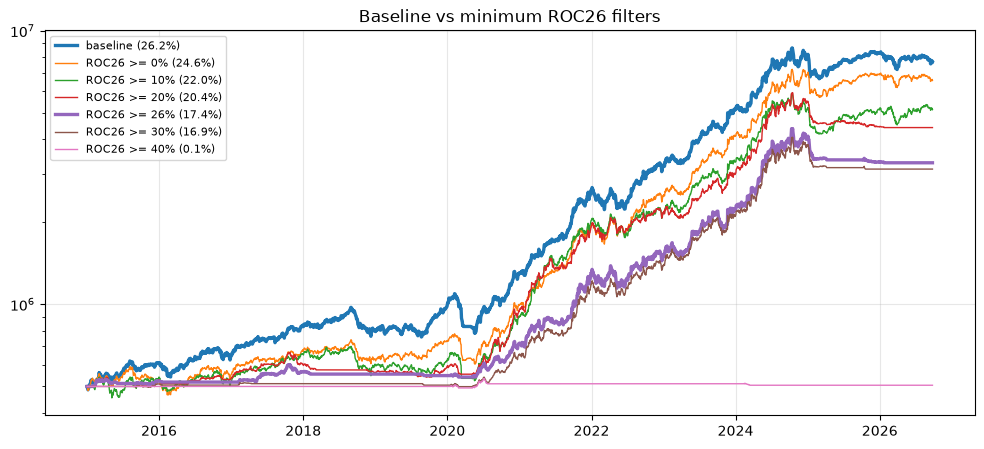

In [20]:
# ==== TEST: minimum 26-day change filter (ROC26 >= X %) — run at the end of ICHIMOKU_FINAL_BACKTEST ====
import numpy as np, pandas as pd, matplotlib.pyplot as plt
THRESHOLDS = [None, 0, 10, 20, 26, 30, 40]     # None = baseline (no filter)
TEST_THR   = 26                                 # the one you want to adopt
N_RANDOM   = 20                                 # random-skip placebo runs

roc = np.nan_to_num(P["roc"], nan=-9.0)         # 26-day change as a fraction (same array the ranking uses)

def run_with(mask):
    P2 = dict(P); P2["sig"] = P["sig"] & mask
    tr, eq, n_open, _ = simulate(P2, CFG, TRAIL)
    return tr, eq, n_open

def sub_cagr(eq, a, b):
    e = eq[(eq.index >= a) & (eq.index < b)]
    yrs = (e.index[-1] - e.index[0]).days / 365.25
    return ((e.iloc[-1] / e.iloc[0]) ** (1 / yrs) - 1) * 100

rows, curves = [], {}
for thr in THRESHOLDS:
    mask = np.ones_like(P["sig"], dtype=bool) if thr is None else (roc >= thr / 100)
    tr, eq, n_open = run_with(mask)
    m = metrics(eq, tr, n_open, CFG)
    name = "baseline" if thr is None else f"ROC26 >= {thr}%"
    curves[name] = eq
    rows.append({"filter": name,
                 "signals kept %": round((P["sig"] & mask).sum() / P["sig"].sum() * 100, 1),
                 "CAGR %": m["CAGR_pct"], "max DD %": m["max_DD_pct"], "Calmar": m["Calmar"], "Sharpe": m["Sharpe"],
                 "trades": m["trades"], "win %": m.get("win_rate_pct"), "profit factor": m.get("profit_factor"),
                 "avg slots used": m.get("avg_slots_used"),
                 "CAGR 2015-20 %": round(sub_cagr(eq, "2015-01-01", "2021-01-01"), 2),
                 "CAGR 2021-now %": round(sub_cagr(eq, "2021-01-01", "2100-01-01"), 2)})
    print("done:", name)
RES = pd.DataFrame(rows).set_index("filter")
display(RES)

# placebo: skip the same share of signals at RANDOM — the ROC filter must beat this
keep = (P["sig"] & (roc >= TEST_THR / 100)).sum() / P["sig"].sum()
rng = np.random.default_rng(1); rand = []
for k in range(N_RANDOM):
    tr, eq, n_open = run_with(rng.random(P["sig"].shape) < keep)
    rand.append(metrics(eq, tr, n_open, CFG)["Calmar"]); print(f"\rrandom {k + 1}/{N_RANDOM}", end="")
rand = np.array(rand, dtype=float); cal = RES.loc[f"ROC26 >= {TEST_THR}%", "Calmar"]
print(f"\nROC26 >= {TEST_THR}% Calmar {cal:.2f} beats {(rand < cal).mean() * 100:.0f}% of random skips "
      f"(random median {np.median(rand):.2f})")

# verdict
b, t = RES.loc["baseline"], RES.loc[f"ROC26 >= {TEST_THR}%"]
nb = [RES.loc[f"ROC26 >= {x}%"] for x in (20, 30) if f"ROC26 >= {x}%" in RES.index]
checks = {
    "higher Calmar AND CAGR not lower":             t["Calmar"] > b["Calmar"] and t["CAGR %"] >= b["CAGR %"],
    "better in BOTH halves (2015-20, 2021-now)":     t["CAGR 2015-20 %"] >= b["CAGR 2015-20 %"] and t["CAGR 2021-now %"] >= b["CAGR 2021-now %"],
    "neighbours 20% and 30% also beat baseline":     all(n["Calmar"] > b["Calmar"] for n in nb),
    "beats >= 90% of random skips":                   (rand < cal).mean() >= 0.9,
}
for k, v in checks.items(): print(("PASS  " if v else "FAIL  ") + k)
print("→ ADOPT the filter (paper-trade it first)" if all(checks.values()) else "→ KEEP the baseline — the 26% filter is not proven")

fig, ax = plt.subplots(figsize=(12, 5))
for n, e in curves.items():
    ax.plot(e, lw=2.4 if n in ("baseline", f"ROC26 >= {TEST_THR}%") else 1, label=f"{n} ({RES.loc[n, 'CAGR %']:.1f}%)")
ax.set_yscale("log"); ax.legend(fontsize=8); ax.grid(alpha=.3); ax.set_title("Baseline vs minimum ROC26 filters"); plt.show()

In [22]:
"""
Ichimoku baseline backtest — Nifty 500 universe, book50 mode (no pyramiding, no added capital)
Paste into a fresh Jupyter cell / .py file and run. Needs internet access + `pip install yfinance pandas numpy`.
"""

import time
import pickle
import requests
import numpy as np
import pandas as pd
import yfinance as yf

# ------------------------------------------------------------------
# 0. CONFIG
# ------------------------------------------------------------------
CFG = dict(
    tenkan=9, kijun=26, senkou_b=52, displacement=26,
    capital=500_000, max_positions=10, alloc_pct=10,     # alloc_pct of CURRENT equity (compounding)
    sl_pct=12, tp_pct=24, book_fraction=0.5,
    trail_pct=30,                                         # 30% trailing stop, ratchets up only, never down
    commission_pct=0.10,
)
DATA_START  = "2014-01-01"          # extra lead-in so indicators are warm by TRADE_START
TRADE_START = "2015-01-01"
END         = None                  # None = up to today
CACHE_FILE  = "nifty500_prices_raw.pkl"

# ------------------------------------------------------------------
# 1. GET NIFTY 500 CONSTITUENTS
# ------------------------------------------------------------------
def get_nifty500_symbols():
    url = "https://nsearchives.nseindia.com/content/indices/ind_nifty500list.csv"
    headers = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)"}
    try:
        r = requests.get(url, headers=headers, timeout=15)
        r.raise_for_status()
        from io import StringIO
        df = pd.read_csv(StringIO(r.text))
        syms = df["Symbol"].str.strip().tolist()
        print(f"Fetched {len(syms)} Nifty 500 symbols from NSE.")
        return [s + ".NS" for s in syms]
    except Exception as e:
        print("Auto-download of Nifty 500 list failed:", e)
        print("Manually download 'ind_nifty500list.csv' from niftyindices.com and place it in this folder,")
        print("then rerun with: syms = pd.read_csv('ind_nifty500list.csv')['Symbol'] + '.NS'")
        raise

SYMBOLS = get_nifty500_symbols()

# ------------------------------------------------------------------
# 2. DOWNLOAD OHLC (cached — only downloads once)
# ------------------------------------------------------------------
def download_data(symbols):
    try:
        with open(CACHE_FILE, "rb") as f:
            data = pickle.load(f)
        print(f"Loaded cached data for {len(data)} symbols.")
        return data
    except FileNotFoundError:
        pass

    data = {}
    batch = 50
    for i in range(0, len(symbols), batch):
        chunk = symbols[i:i+batch]
        print(f"Downloading {i+1}-{i+len(chunk)} / {len(symbols)} ...")
        try:
            raw = yf.download(chunk, start=DATA_START, end=END, auto_adjust=False,
                               group_by="ticker", threads=True, progress=False)
        except Exception as e:
            print("Batch failed:", e)
            continue
        for s in chunk:
            try:
                df = raw[s][["Open", "High", "Low", "Close"]].dropna()
                if len(df) > CFG["senkou_b"] + CFG["displacement"] + 5:
                    data[s] = df
            except Exception:
                continue
        time.sleep(1)  # be polite to Yahoo's endpoint

    with open(CACHE_FILE, "wb") as f:
        pickle.dump(data, f)
    print(f"Downloaded and cached {len(data)} symbols.")
    return data

data = download_data(SYMBOLS)

# ------------------------------------------------------------------
# 3. INDICATORS + ENTRY SIGNAL  (identical to the notebook: price_kijun / strong)
# ------------------------------------------------------------------
xover = lambda a, b: (a > b) & (a.shift(1) <= b.shift(1))

def add_indicators(df, c):
    hi, lo, cl = df["High"], df["Low"], df["Close"]
    donch = lambda n: (lo.rolling(n).min() + hi.rolling(n).max()) / 2
    df = df.copy()
    df["tenkan"] = donch(c["tenkan"])
    df["kijun"]  = donch(c["kijun"])
    df["span_a"] = (df["tenkan"] + df["kijun"]) / 2
    df["span_b"] = donch(c["senkou_b"])
    sh = c["displacement"] - 1
    df["adj_a"] = df["span_a"].shift(sh)     # cloud line as currently displayed
    df["adj_b"] = df["span_b"].shift(sh)
    df["roc"]   = cl.pct_change(26)          # ranking metric
    return df

def entry_signal(df):
    c = df["Close"]
    return (xover(c, df["kijun"]) & (c > df["adj_a"])).fillna(False)   # ('price_kijun','strong')

processed = {}
for s, df in data.items():
    if len(df) < CFG["senkou_b"] + CFG["displacement"] + 5:
        continue
    d = add_indicators(df, CFG)
    d["signal"] = entry_signal(d)
    processed[s] = d

print(f"Indicators computed for {len(processed)} symbols.")

# ------------------------------------------------------------------
# 4. BUILD ALIGNED DATE INDEX
# ------------------------------------------------------------------
all_dates = sorted(set().union(*[d.index for d in processed.values()]))
all_dates = pd.DatetimeIndex(all_dates)

if END is None:
    trade_dates = all_dates[all_dates >= TRADE_START]
else:
    trade_dates = all_dates[(all_dates >= TRADE_START) & (all_dates <= END)]
# ------------------------------------------------------------------
# 5. EVENT-DRIVEN BACKTEST — book50 baseline, no pyramiding
# ------------------------------------------------------------------
cash = CFG["capital"]
positions = {}      # symbol -> dict(qty, entry_px, sl_px, tp_px, peak_close, booked)
trades = []
equity_curve = []

comm = CFG["commission_pct"] / 100

for dt in trade_dates:
    # ---- 5a. mark-to-market + process exits for open positions ----
    for sym in list(positions.keys()):
        if dt not in processed[sym].index:
            continue
        row = processed[sym].loc[dt]
        pos = positions[sym]

        pos["peak_close"] = max(pos["peak_close"], row["Close"])
        trail_level = pos["peak_close"] * (1 - CFG["trail_pct"] / 100)
        stop = max(pos["sl_px"], trail_level)          # ratchets up only — breakeven-or-better once profitable
        reason = "TRAIL" if trail_level >= pos["sl_px"] else "SL"

        # stop-loss / trailing-stop check first
        if row["Low"] <= stop:
            fill = min(row["Open"], stop)
            proceeds = pos["qty"] * fill * (1 - comm)
            cash += proceeds
            pnl = proceeds - pos["qty"] * pos["entry_px"] * (1 + comm) * (pos["qty"] / pos["orig_qty"])
            trades.append(dict(symbol=sym, entry_date=pos["entry_date"], exit_date=dt,
                                entry_px=pos["entry_px"], exit_px=fill, qty=pos["qty"],
                                pnl=pnl, reason=reason, booked=pos["booked"]))
            del positions[sym]
            continue

        # target check (book 50%) — only once
        if (not pos["booked"]) and row["High"] >= pos["tp_px"]:
            fill = max(row["Open"], pos["tp_px"])
            sell_qty = int(pos["qty"] * CFG["book_fraction"])
            if sell_qty > 0:
                proceeds = sell_qty * fill * (1 - comm)
                cash += proceeds
                trades.append(dict(symbol=sym, entry_date=pos["entry_date"], exit_date=dt,
                                    entry_px=pos["entry_px"], exit_px=fill, qty=sell_qty,
                                    pnl=proceeds - sell_qty * pos["entry_px"] * (1 + comm),
                                    reason="TARGET_BOOK50", booked=True))
                pos["qty"] -= sell_qty
                pos["booked"] = True

    # ---- 5b. mark remaining open positions to today's close for equity ----
    mtm = sum(positions[s]["qty"] * processed[s].loc[dt, "Close"]
              for s in positions if dt in processed[s].index)
    current_equity = cash + mtm

    # ---- 5c. new entries ----
    open_slots = CFG["max_positions"] - len(positions)
    if open_slots > 0:
        candidates = []
        for s, d in processed.items():
            if s in positions or dt not in d.index:
                continue
            if d.loc[dt, "signal"]:
                candidates.append((s, d.loc[dt, "roc"], d.loc[dt, "Close"]))
        candidates.sort(key=lambda x: -x[1] if pd.notna(x[1]) else -np.inf)

        for s, roc, px in candidates[:open_slots]:
            alloc = current_equity * CFG["alloc_pct"] / 100
            qty = int(alloc / px)
            if qty <= 0:
                continue
            cost = qty * px * (1 + comm)
            if cost > cash:
                continue
            cash -= cost
            positions[s] = dict(qty=qty, orig_qty=qty, entry_px=px, entry_date=dt,
                                 sl_px=px * (1 - CFG["sl_pct"] / 100),
                                 tp_px=px * (1 + CFG["tp_pct"] / 100),
                                 peak_close=px, booked=False)

    mtm = sum(positions[s]["qty"] * processed[s].loc[dt, "Close"]
              for s in positions if dt in processed[s].index)
    equity_curve.append((dt, cash + mtm, len(positions)))

# ------------------------------------------------------------------
# 6. METRICS
# ------------------------------------------------------------------
eq = pd.DataFrame(equity_curve, columns=["date", "equity", "open_positions"]).set_index("date")
trades_df = pd.DataFrame(trades)

initial_capital = CFG["capital"]
final_equity = eq["equity"].iloc[-1]
net_pnl = final_equity - initial_capital
total_return = final_equity / initial_capital - 1
years = (eq.index[-1] - eq.index[0]).days / 365.25
cagr = (final_equity / initial_capital) ** (1 / years) - 1

roll_max = eq["equity"].cummax()
drawdown = eq["equity"] / roll_max - 1
max_dd_pct = drawdown.min() * 100
max_dd_rs = (eq["equity"] - roll_max).min()

wins = trades_df[trades_df["pnl"] > 0]
losses = trades_df[trades_df["pnl"] <= 0]
win_rate = len(wins) / len(trades_df) * 100 if len(trades_df) else 0
profit_factor = wins["pnl"].sum() / abs(losses["pnl"].sum()) if len(losses) and losses["pnl"].sum() != 0 else np.nan

print("=" * 60)
print("ICHIMOKU BASELINE (book50) — NIFTY 500 — PERFORMANCE SUMMARY")
print("=" * 60)
print(f"Initial capital     : Rs {initial_capital:,.0f}")
print(f"Final equity        : Rs {final_equity:,.0f}")
print(f"Net P&L             : Rs {net_pnl:,.0f}  ({total_return*100:.1f}%)")
print(f"CAGR                : {cagr*100:.2f}%")
print(f"Max drawdown        : {max_dd_pct:.2f}%  (Rs {max_dd_rs:,.0f})")
print(f"Total trade legs    : {len(trades_df)}")
print(f"Winning legs        : {len(wins)}")
print(f"Losing legs         : {len(losses)}")
print(f"Win rate            : {win_rate:.1f}%")
print(f"Profit factor       : {profit_factor:.2f}")
print("=" * 60)

trades_df.to_csv("nifty500_trades_book50.csv", index=False)
eq.to_csv("nifty500_equity_book50.csv")
print("Saved: nifty500_trades_book50.csv, nifty500_equity_book50.csv")

Fetched 501 Nifty 500 symbols from NSE.
Loaded cached data for 500 symbols.
Indicators computed for 500 symbols.
ICHIMOKU BASELINE (book50) — NIFTY 500 — PERFORMANCE SUMMARY
Initial capital     : Rs 500,000
Final equity        : Rs 2,833,996
Net P&L             : Rs 2,333,996  (466.8%)
CAGR                : 15.94%
Max drawdown        : -30.23%  (Rs -973,462)
Total trade legs    : 219
Winning legs        : 129
Losing legs         : 90
Win rate            : 58.9%
Profit factor       : 3.43
Saved: nifty500_trades_book50.csv, nifty500_equity_book50.csv


In [23]:
# ------------------------------------------------------------------
# 5b. RERUN WITH NO CAP ON NUMBER OF OPEN POSITIONS
# (reuses `processed` and `trade_dates` from the cells above — no re-download needed)
# ------------------------------------------------------------------
CFG_NOCAP = dict(CFG)
CFG_NOCAP["max_positions"] = 10_000   # effectively unlimited — cash on hand is the real constraint now

cash = CFG_NOCAP["capital"]
positions = {}
trades_nocap = []
equity_curve_nocap = []
comm = CFG_NOCAP["commission_pct"] / 100

for dt in trade_dates:
    # ---- exits (identical logic to the capped run) ----
    for sym in list(positions.keys()):
        if dt not in processed[sym].index:
            continue
        row = processed[sym].loc[dt]
        pos = positions[sym]

        pos["peak_close"] = max(pos["peak_close"], row["Close"])
        trail_level = pos["peak_close"] * (1 - CFG_NOCAP["trail_pct"] / 100)
        stop = max(pos["sl_px"], trail_level)
        reason = "TRAIL" if trail_level >= pos["sl_px"] else "SL"

        if row["Low"] <= stop:
            fill = min(row["Open"], stop)
            proceeds = pos["qty"] * fill * (1 - comm)
            cash += proceeds
            pnl = proceeds - pos["qty"] * pos["entry_px"] * (1 + comm) * (pos["qty"] / pos["orig_qty"])
            trades_nocap.append(dict(symbol=sym, entry_date=pos["entry_date"], exit_date=dt,
                                      entry_px=pos["entry_px"], exit_px=fill, qty=pos["qty"],
                                      pnl=pnl, reason=reason, booked=pos["booked"]))
            del positions[sym]
            continue

        if (not pos["booked"]) and row["High"] >= pos["tp_px"]:
            fill = max(row["Open"], pos["tp_px"])
            sell_qty = int(pos["qty"] * CFG_NOCAP["book_fraction"])
            if sell_qty > 0:
                proceeds = sell_qty * fill * (1 - comm)
                cash += proceeds
                trades_nocap.append(dict(symbol=sym, entry_date=pos["entry_date"], exit_date=dt,
                                          entry_px=pos["entry_px"], exit_px=fill, qty=sell_qty,
                                          pnl=proceeds - sell_qty * pos["entry_px"] * (1 + comm),
                                          reason="TARGET_BOOK50", booked=True))
                pos["qty"] -= sell_qty
                pos["booked"] = True

    mtm = sum(positions[s]["qty"] * processed[s].loc[dt, "Close"]
              for s in positions if dt in processed[s].index)
    current_equity = cash + mtm

    # ---- new entries: no slot cap, just take every signal you can afford ----
    candidates = []
    for s, d in processed.items():
        if s in positions or dt not in d.index:
            continue
        if d.loc[dt, "signal"]:
            candidates.append((s, d.loc[dt, "roc"], d.loc[dt, "Close"]))
    candidates.sort(key=lambda x: -x[1] if pd.notna(x[1]) else -np.inf)

    for s, roc, px in candidates:
        alloc = current_equity * CFG_NOCAP["alloc_pct"] / 100
        qty = int(alloc / px)
        if qty <= 0:
            continue
        cost = qty * px * (1 + comm)
        if cost > cash:
            continue          # out of cash — this is now the only limit
        cash -= cost
        positions[s] = dict(qty=qty, orig_qty=qty, entry_px=px, entry_date=dt,
                             sl_px=px * (1 - CFG_NOCAP["sl_pct"] / 100),
                             tp_px=px * (1 + CFG_NOCAP["tp_pct"] / 100),
                             peak_close=px, booked=False)

    mtm = sum(positions[s]["qty"] * processed[s].loc[dt, "Close"]
              for s in positions if dt in processed[s].index)
    equity_curve_nocap.append((dt, cash + mtm, len(positions)))

# ------------------------------------------------------------------
# 6b. METRICS — no-cap run
# ------------------------------------------------------------------
eq_nocap = pd.DataFrame(equity_curve_nocap, columns=["date", "equity", "open_positions"]).set_index("date")
trades_df_nocap = pd.DataFrame(trades_nocap)

initial_capital = CFG_NOCAP["capital"]
final_equity = eq_nocap["equity"].iloc[-1]
net_pnl = final_equity - initial_capital
total_return = final_equity / initial_capital - 1
years = (eq_nocap.index[-1] - eq_nocap.index[0]).days / 365.25
cagr = (final_equity / initial_capital) ** (1 / years) - 1

roll_max = eq_nocap["equity"].cummax()
drawdown = eq_nocap["equity"] / roll_max - 1
max_dd_pct = drawdown.min() * 100
max_dd_rs = (eq_nocap["equity"] - roll_max).min()

wins = trades_df_nocap[trades_df_nocap["pnl"] > 0]
losses = trades_df_nocap[trades_df_nocap["pnl"] <= 0]
win_rate = len(wins) / len(trades_df_nocap) * 100 if len(trades_df_nocap) else 0
profit_factor = wins["pnl"].sum() / abs(losses["pnl"].sum()) if len(losses) and losses["pnl"].sum() != 0 else np.nan

print("=" * 60)
print("ICHIMOKU BASELINE (book50) — NIFTY 500 — NO POSITION CAP")
print("=" * 60)
print(f"Initial capital     : Rs {initial_capital:,.0f}")
print(f"Final equity        : Rs {final_equity:,.0f}")
print(f"Net P&L             : Rs {net_pnl:,.0f}  ({total_return*100:.1f}%)")
print(f"CAGR                : {cagr*100:.2f}%")
print(f"Max drawdown        : {max_dd_pct:.2f}%  (Rs {max_dd_rs:,.0f})")
print(f"Total trade legs    : {len(trades_df_nocap)}")
print(f"Winning legs        : {len(wins)}")
print(f"Losing legs         : {len(losses)}")
print(f"Win rate            : {win_rate:.1f}%")
print(f"Profit factor       : {profit_factor:.2f}")
print(f"Peak concurrent open positions: {eq_nocap['open_positions'].max()}")
print("=" * 60)

trades_df_nocap.to_csv("nifty500_trades_book50_nocap.csv", index=False)
eq_nocap.to_csv("nifty500_equity_book50_nocap.csv")
print("Saved: nifty500_trades_book50_nocap.csv, nifty500_equity_book50_nocap.csv")

ICHIMOKU BASELINE (book50) — NIFTY 500 — NO POSITION CAP
Initial capital     : Rs 500,000
Final equity        : Rs 7,460,645
Net P&L             : Rs 6,960,645  (1392.1%)
CAGR                : 25.91%
Max drawdown        : -32.31%  (Rs -2,757,799)
Total trade legs    : 273
Winning legs        : 170
Losing legs         : 103
Win rate            : 62.3%
Profit factor       : 3.64
Peak concurrent open positions: 16
Saved: nifty500_trades_book50_nocap.csv, nifty500_equity_book50_nocap.csv


In [25]:
pip install plotly

  Using cached plotly-7.1.0-py3-none-any.whl.metadata (8.8 kB)
Using cached plotly-7.1.0-py3-none-any.whl (9.7 MB)
Note: you may need to restart the kernel to use updated packages.


In [28]:
# ------------------------------------------------------------------
# 7. INTERACTIVE GUI (matplotlib) — entries, partial booking, exits on a line chart
# Reuses `processed`, `trades_df`, `eq`, `CFG` from the earlier cells.
# ------------------------------------------------------------------
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import ipywidgets as widgets
from IPython.display import display

SOURCE = "capped"   # "capped" or "nocap"

if SOURCE == "capped":
    _trades, _eq, _cfg = trades_df, eq, CFG
else:
    _trades, _eq, _cfg = trades_df_nocap, eq_nocap, CFG_NOCAP

# ---- reconstruct one "episode" per position (merge partial-book leg + final exit leg) ----
def build_episodes(trades):
    eps = []
    for (sym, edate), grp in trades.groupby(["symbol", "entry_date"]):
        grp = grp.sort_values("exit_date")
        entry_px = grp.iloc[0]["entry_px"]
        book_leg = grp[grp["reason"] == "TARGET_BOOK50"]
        final_leg = grp[grp["reason"].isin(["SL", "TRAIL"])]
        if len(final_leg):
            exit_date, exit_px, exit_reason = final_leg.iloc[0][["exit_date", "exit_px", "reason"]]
        else:
            exit_date, exit_px, exit_reason = grp.iloc[-1][["exit_date", "exit_px", "reason"]]
        eps.append(dict(
            symbol=sym, entry_date=edate, entry_px=entry_px,
            booked=len(book_leg) > 0,
            book_date=book_leg.iloc[0]["exit_date"] if len(book_leg) else None,
            book_px=book_leg.iloc[0]["exit_px"] if len(book_leg) else None,
            exit_date=exit_date, exit_px=exit_px, exit_reason=exit_reason,
            total_pnl=grp["pnl"].sum(),
        ))
    return pd.DataFrame(eps)

episodes_df = build_episodes(_trades)
symbols_with_trades = sorted(episodes_df["symbol"].unique())
print(f"{len(symbols_with_trades)} symbols with trades available.")

# ---- per-symbol matplotlib chart ----
def plot_symbol(sym):
    df = processed[sym]
    eps = episodes_df[episodes_df["symbol"] == sym].sort_values("entry_date")

    pad = pd.Timedelta(days=20)
    lo = eps["entry_date"].min() - pad
    hi = (eps["exit_date"].max() if eps["exit_date"].notna().any() else eps["entry_date"].max()) + pad
    view = df.loc[(df.index >= lo) & (df.index <= hi)]

    fig, ax = plt.subplots(figsize=(13, 6))
    ax.plot(view.index, view["Close"], color="black", linewidth=1.2, label=sym)

    for _, ep in eps.iterrows():
        entry_px = ep["entry_px"]
        sl_px = entry_px * (1 - _cfg["sl_pct"] / 100)
        tp_px = entry_px * (1 + _cfg["tp_pct"] / 100)
        span = df.loc[(df.index >= ep["entry_date"]) & (df.index <= ep["exit_date"])]

        peak, trail_line, dates = entry_px, [], []
        for dt, row in span.iterrows():
            peak = max(peak, row["Close"])
            stop = max(sl_px, peak * (1 - _cfg["trail_pct"] / 100))
            trail_line.append(stop)
            dates.append(dt)

        ax.plot(dates, [sl_px] * len(dates), color="red", linestyle=":", linewidth=1)
        ax.plot(dates, [tp_px] * len(dates), color="green", linestyle=":", linewidth=1)
        ax.plot(dates, trail_line, color="purple", linestyle="--", linewidth=1.3)

        ax.scatter(ep["entry_date"], entry_px, color="green", marker="^", s=110, zorder=5)
        ax.annotate("ENTRY", (ep["entry_date"], entry_px), textcoords="offset points",
                    xytext=(0, -14), ha="center", fontsize=8, color="green")

        if ep["booked"]:
            ax.scatter(ep["book_date"], ep["book_px"], color="orange", marker="D", s=90, zorder=5)
            ax.annotate("BOOK 50%", (ep["book_date"], ep["book_px"]), textcoords="offset points",
                        xytext=(0, 10), ha="center", fontsize=8, color="orange")

        if pd.notna(ep["exit_date"]):
            color = "red" if ep["exit_reason"] == "SL" else "blue"
            ax.scatter(ep["exit_date"], ep["exit_px"], color=color, marker="x", s=110, zorder=5)
            ax.annotate(f"EXIT ({ep['exit_reason']})", (ep["exit_date"], ep["exit_px"]),
                        textcoords="offset points", xytext=(0, 10), ha="center", fontsize=8, color=color)

    ax.set_title(f"{sym} — trade lifecycle")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    fig.autofmt_xdate()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    display(eps[["entry_date", "entry_px", "booked", "book_date", "book_px",
                 "exit_date", "exit_px", "exit_reason", "total_pnl"]])

# ---- equity curve + drawdown ----
def plot_equity():
    roll_max = _eq["equity"].cummax()
    dd = (_eq["equity"] / roll_max - 1) * 100

    fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True,
                              gridspec_kw={"height_ratios": [3, 1]})
    axes[0].plot(_eq.index, _eq["equity"], color="royalblue")
    axes[0].set_title("Equity curve")
    axes[0].grid(alpha=0.3)

    axes[1].fill_between(_eq.index, dd, 0, color="crimson", alpha=0.5)
    axes[1].set_title("Drawdown %")
    axes[1].grid(alpha=0.3)

    axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    fig.autofmt_xdate()
    plt.tight_layout()
    plt.show()

# ---- GUI: dropdown selector ----
symbol_dd = widgets.Dropdown(options=symbols_with_trades, description="Symbol:")
out = widgets.Output()

def on_change(change):
    with out:
        out.clear_output(wait=True)
        plot_symbol(change["new"])

symbol_dd.observe(on_change, names="value")

tabs = widgets.Tab()
tab1 = widgets.VBox([symbol_dd, out])
tab2_out = widgets.Output()
with tab2_out:
    plot_equity()
tabs.children = [tab1, tab2_out]
tabs.set_title(0, "Trade lifecycle")
tabs.set_title(1, "Equity / Drawdown")

display(tabs)
on_change({"new": symbol_dd.value})   # render first symbol immediately

128 symbols with trades available.
